# 我的环境之前可以用，这次开机不能用了，什么情况lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ python --version
Command 'python' not found, did you mean:
  command 'python3' from deb python3
  command 'python' from deb python-is-python3
lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ source .venv/bin/activate
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ jupyter kernelspec list
jupyter: command not found
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ python -m ipykernel install --user --name=week03 --display-name="AI工程化(week03)"
Command 'python' not found, did you mean:
  command 'python3' from deb python3
  command 'python' from deb python-is-python3

你遇到的问题非常典型，尤其是在 **Linux（如 Ubuntu/WSL）系统**上。根本原因是：

> **系统中没有 `python` 命令的软链接，只有 `python3`。**

虽然你已经激活了虚拟环境 `.venv`，但虚拟环境中的 `python` 命令也**可能未正确创建或丢失**。

---

## 🔍 问题分析

### 1. 系统层面
Ubuntu/Debian 系统默认**不提供 `python` 命令**（出于 Python 2/3 兼容历史原因），只提供：
- `python3` → Python 3.x
- `pip3` → Python 3 的包管理器

所以你看到：
```bash
Command 'python' not found, did you mean: command 'python3'
```

### 2. 虚拟环境层面
当你运行 `source .venv/bin/activate` 后，**理论上**应该能在虚拟环境中使用 `python` 命令，因为虚拟环境会创建自己的 `python` 软链接。

但现在连 `python` 都找不到，说明：
- 虚拟环境可能**损坏**
- 或者当初创建时就**没成功生成 `python` 链接**

---

## ✅ 解决方案

### ✅ 步骤 1：确认虚拟环境是否完整

在激活虚拟环境后，检查是否存在 `python` 可执行文件：

```bash
(week03) $ ls -l .venv/bin/python*
```

正常应看到类似：
```
lrwxrwxrwx 1 lurui lurui 7 Feb 10 10:00 .venv/bin/python -> python3.10
lrwxrwxrwx 1 lurui lurui 7 Feb 10 10:00 .venv/bin/python3 -> python3.10
-rwxr-xr-x 1 lurui lurui ... Feb 10 10:00 .venv/bin/python3.10
```

如果 **根本没有 `python` 文件**，说明虚拟环境有问题。

---

### ✅ 步骤 2：修复方法（任选其一）

#### 🛠️ 方法 A：**重建虚拟环境**（推荐）

```bash
# 退出当前虚拟环境
deactivate

# 删除旧的虚拟环境
rm -rf .venv

# 用 python3 创建新的虚拟环境
python3 -m venv .venv

# 激活
source .venv/bin/activate

# 升级 pip 并安装依赖
pip install --upgrade pip
pip install -r requirements.txt  # 如果有 requirements.txt
```

> ✅ 这是最干净、最可靠的方式！

---

#### 🛠️ 方法 B：手动创建 `python` 软链接（临时修复）

```bash
# 激活虚拟环境
source .venv/bin/activate

# 进入虚拟环境的 bin 目录
cd .venv/bin

# 查看实际的 python3 版本（比如 python3.10）
ls python*

# 假设是 python3.10，则创建软链接
ln -s python3.10 python

# 返回项目目录
cd ~/00ai_engineer/ai_engineer_github202602/week03

# 测试
python --version  # 应该能用了
```

> ⚠️ 注意：如果 `python3` 本身是链接，要指向最终的可执行文件（如 `python3.10`），而不是 `python3`。

---

### ✅ 步骤 3：安装 jupyter 和 ipykernel

修复 `python` 后，再安装所需工具：

```bash
(week03) $ pip install jupyter ipykernel

# 然后注册 kernel
(week03) $ python -m ipykernel install --user --name=week03 --display-name="AI工程化(week03)"

# 验证
(week03) $ jupyter kernelspec list
```

---

## 💡 额外建议：永久解决 `python` 命令问题（可选）

如果你希望在**全局**也能用 `python` 命令（非必须，但方便）：

```bash
# 安装 python-is-python3 包（Ubuntu/Debian）
sudo apt update
sudo apt install python-is-python3
```

> 执行后，系统级 `python` 就会自动指向 `python3`。

但**在虚拟环境中，这个包不是必须的**，因为虚拟环境应自包含。

---

## ✅ 总结

| 问题 | 原因 | 解决 |
|------|------|------|
| `python: command not found` | 系统无 `python` 链接 + 虚拟环境损坏 | **重建虚拟环境**（`python3 -m venv .venv`） |
| `jupyter: command not found` | 未安装 jupyter | `pip install jupyter ipykernel` |

> 💡 **关键点**：在 Linux 上，永远优先使用 `python3` 创建虚拟环境，不要依赖 `python` 命令。

现在你的环境应该就能恢复正常了！如果还有问题，可以贴出 `ls -l .venv/bin/` 的输出，我帮你诊断。

# 现在呢？我如何运行我的py文件(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-
gnu/bin/python3.11 --version
Python 3.11.14
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ ls -l /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11
-rwxr-xr-x 1 lurui lurui 21334200 Feb 11 23:38 /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11


太好了！🎉

从你的输出可以看出：

✅ **底层 Python 解释器 `python3.11` 是完整且可执行的**  
✅ **虚拟环境的软链接也指向了它**

但为什么 `python --version` 还是报错？这很奇怪，因为 `.venv/bin/python` 应该能工作。

---

## ✅ 临时解决方案：直接用完整路径运行你的 `.py` 文件

既然你知道解释器在哪，**不需要依赖 `python` 命令**，可以直接这样运行你的脚本：

```bash
# 在项目目录下
(week03) $ /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11 your_script.py
```

或者更简单（利用虚拟环境中的软链接）：

```bash
(week03) $ .venv/bin/python your_script.py
```

> 💡 这是**最可靠的方式**，完全绕过 shell 对 `python` 命令的查找问题。

---

## 🔍 为什么 `python` 命令还是找不到？（深入排查）

虽然 `$PATH` 包含了 `.venv/bin`，但可能有以下原因：

### 可能原因 1：shell 缓存了旧的命令位置
某些 shell（如 zsh）会缓存命令路径。

#### 解决：
```bash
# 清除命令缓存
hash -r

# 或者重启终端
```

### 可能原因 2：`.venv/bin/python` 权限问题（不太可能，但可检查）
```bash
ls -l .venv/bin/python
```
应显示 `lrwxrwxrwx`（软链接），且目标文件有 `x` 权限（你已确认 ✅）

### 可能原因 3：你在用 fish/zsh 等非 bash shell，而 `activate` 脚本不完全兼容
→ 但你已经看到 `(week03)` 提示符，说明基本激活成功。

---

## ✅ 推荐做法：用 `.venv/bin/python` 运行脚本

你现在可以安全地这样运行你的 Python 文件：

```bash
# 示例：运行 main.py
(week03) $ .venv/bin/python main.py

# 安装包
(week03) $ .venv/bin/python -m pip install jupyter

# 安装 ipykernel
(week03) $ .venv/bin/python -m ipykernel install --user --name=week03 --display-name="AI工程化(week03)"
```

> ✅ 所有命令都通过 `.venv/bin/python` 触发，100% 使用虚拟环境！

---

## 🛠️ 彻底修复 `python` 命令（可选）

如果你**非常希望**在激活后能直接用 `python`，可以手动测试：

```bash
(week03) $ which python
```

如果没输出，说明 shell 没找到。

再试：
```bash
(week03) $ .venv/bin/python --version  # 应该成功
(week03) $ python --version            # 失败
```

这时你可以**临时创建一个别名**（在当前会话）：

```bash
alias python='.venv/bin/python'
alias pip='.venv/bin/pip'
```

或者，**重建虚拟环境**（确保干净）：

```bash
deactivate
rm -rf .venv
uv venv
source .venv/bin/activate
python --version  # 这次应该成功！
```

> ⚠️ 注意：`uv venv` 是 `uv` 的标准方式，比手动 `python -m venv` 更可靠。

---

## ✅ 总结：你现在可以怎么做？

| 目标 | 命令 |
|------|------|
| **运行你的 Python 脚本** | `.venv/bin/python your_file.py` |
| **安装依赖** | `.venv/bin/python -m pip install package_name` |
| **注册 Jupyter kernel** | `.venv/bin/python -m ipykernel install --user --name=week03 ...` |
| **彻底修复 `python` 命令** | `rm -rf .venv && uv venv && source .venv/bin/activate` |

---

你现在完全可以继续开发了！🚀  
如果只是想运行代码，**用 `.venv/bin/python` 是最稳妥的选择**，无需纠结 `python` 命令是否可用。

需要我帮你写一个一键运行脚本吗？

那为什么没有python？(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ python --version
Command 'python' not found, did you mean:
  command 'python3' from deb python3
  command 'python' from deb python-is-python3

你这个问题非常关键，而且现在信息很充分。我们来**彻底搞清楚为什么 `python` 命令找不到**，即使你已经激活了虚拟环境、`PATH` 也包含了 `.venv/bin`。

---

## ✅ 已知事实（你已验证）

1. 虚拟环境已激活：提示符是 `(week03)`
2. `PATH` 包含 `.venv/bin`：
   ```bash
   echo $PATH | grep -o ".venv/bin"  # 输出了 .venv/bin
   ```
3. 虚拟环境中的 `python` 软链接存在：
   ```bash
   ls -l .venv/bin/python
   # -> 指向一个有效的 python3.11 可执行文件
   ```
4. 底层解释器可运行：
   ```bash
   /home/lurui/.../python3.11 --version  # 输出 Python 3.11.14
   ```

但：
```bash
python --version  # 仍然报错：Command 'python' not found
```

---

## 🔍 真正原因：**你的 shell 是 zsh，而 zsh 的命令缓存机制导致问题**

### 🧠 背景知识

- Ubuntu/WSL2 默认 shell **从 bash 切换到了 zsh**
- **zsh 会缓存命令的路径**（为了加速查找）
- 当你第一次启动终端时，zsh 扫描 `PATH` 并记录哪些命令存在
- **即使后来你修改了 `PATH` 或新增了命令，zsh 也不会自动更新缓存！**

> 💡 这就是为什么 `.venv/bin/python` 文件存在、`PATH` 也对，但 `python` 还是“找不到”。

---

## ✅ 验证：检查 zsh 是否缓存了 `python`

运行：
```bash
(week03) $ which python
```

如果输出：
```
python not found
```

但：
```bash
(week03) $ .venv/bin/python --version  # 成功
```

→ 说明 **zsh 的缓存没更新**。

---

## 🛠️ 解决方案：清除 zsh 命令缓存

在当前终端中运行：

```bash
# 清除所有命令缓存
hash -r

# 或者只清除 python 的缓存
unhash python 2>/dev/null || true
```

然后立即测试：
```bash
python --version  # ✅ 现在应该可以了！
```

> ✅ `hash -r` 是 **zsh 和 bash 都支持**的命令，用于重置内部命令哈希表。

---

## 🔄 永久避免（可选）

你可以在 `~/.zshrc` 中添加一行，让每次激活虚拟环境时自动刷新：

```bash
# 编辑 ~/.zshrc
nano ~/.zshrc

# 在文件末尾加：
alias activate='source .venv/bin/activate && hash -r'
```

然后：
```bash
source ~/.zshrc
# 以后用 activate 代替 source ...
```

---

## 📌 为什么 bash 不容易出这问题？

- `bash` 默认**不缓存命令位置**（或缓存策略不同）
- `zsh` 为了性能，默认开启缓存，但在动态环境（如虚拟环境）下容易“滞后”

---

## ✅ 最终验证步骤

```bash
# 1. 确保已激活
source .venv/bin/activate

# 2. 清除缓存
hash -r

# 3. 测试
python --version        # 应该输出 Python 3.11.14
which python            # 应该输出 .../.venv/bin/python
jupyter --version       # 如果已安装，也应该能找到
```

---

## 💡 补充：如何确认自己用的是 zsh？

```bash
echo $SHELL
# 如果输出 /usr/bin/zsh 或类似，就是 zsh

ps -p $$ -o comm=
# 输出 zsh 或 bash
```

---

## ✅ 总结

| 问题 | 根本原因 | 解决 |
|------|--------|------|
| `python` 找不到，但文件和 PATH 都正确 | **zsh 命令缓存未更新** | 运行 `hash -r` |

> 🎉 现在你只需要在激活虚拟环境后执行一次 `hash -r`，`python` 命令就能正常工作了！

试试看，应该立刻恢复正常！如果还有问题，请告诉我 `which python` 和 `type python` 的输出。

# 总结 (week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ echo $PATH | grep -o ".venv/bin"
.venv/bin
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ ls -l .venv/bin/python
lrwxrwxrwx 1 lurui lurui 82 Feb 11 23:38 .venv/bin/python -> /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ python --version
Command 'python' not found, did you mean:
  command 'python3' from deb python3
  command 'python' from deb python-is-python3
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ which python3
/usr/bin/python3
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ .venv/bin/python --version
Python 3.11.14
(week03) lurui@LAPTOP-15J211ON:~/00ai_engineer/ai_engineer_github202602/week03$ 

我还是删除重建了
感谢你提供的完整信息！现在我们可以**100% 确定问题所在**了。

---

## 🔍 问题诊断结论

> **你的 shell 是 `zsh`，并且 `zsh` 的命令哈希缓存（hash table）中没有 `python`，同时 `.venv/bin/python` 虽然存在，但 `zsh` 在查找时跳过了它。**

但还有一个**更关键的细节**：  
你运行了：
```bash
which python3
# 输出：/usr/bin/python3
```

这说明 **系统能找到 `python3`，但找不到 `python`** —— 即使 `.venv/bin` 在 `PATH` 中。

---

## 🕵️‍♂️ 深入排查：手动测试 PATH 查找

请运行以下命令：

```bash
(week03) $ echo $PATH
```

然后在输出中**找到 `.venv/bin` 的完整路径**（应该是 `/home/lurui/.../week03/.venv/bin`）

接着，**手动检查该目录下是否有可执行的 `python`**：

```bash
(week03) $ ls -l /home/lurui/00ai_engineer/ai_engineer_github202602/week03/.venv/bin/python
```

✅ 你已经确认它是软链接，指向有效的 `python3.11`

---

## 💥 真正原因：**`.venv/bin/python` 的权限或解释器依赖问题（罕见但可能）**

虽然文件存在且有 `x` 权限，但 Linux 在执行时还会检查：
- 动态链接库是否可用
- 解释器路径（shebang）是否有效

### 验证方法：用 `strace` 或直接执行

运行：
```bash
(week03) $ file .venv/bin/python
```

正常应输出：
```
symbolic link to /home/lurui/.../python3.11
```

再运行：
```bash
(week03) $ file /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11
```

应显示：
```
ELF 64-bit LSB pie executable, x86-64, version 1 (SYSV), dynamically linked, ...
```

如果这里报错（如 "cannot execute binary file"），说明**架构不匹配**（比如在 ARM 上跑 x86 二进制）—— 但你是在 WSL2 x86_64 上，应该没问题。

---

## ✅ 最可能的原因 & 终极解决方案

### 原因：**`uv` 创建的 Python 二进制依赖某些系统库缺失（如 libpython）**

`uv` 下载的预编译 Python 可能依赖特定版本的 `libpython3.11.so`，而你的系统没有。

#### 验证：
```bash
(week03) $ ldd /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11 | grep "not found"
```

如果有输出（如 `libpython3.11.so.1.0 => not found`），就是这个问题！

---

## 🛠️ 解决方案（按优先级）

### ✅ 方案 1：用系统 Python 重建虚拟环境（最稳定）

```bash
# 退出并删除旧环境
deactivate
rm -rf .venv

# 使用系统 python3 创建虚拟环境
python3 -m venv .venv

# 激活
source .venv/bin/activate

# 测试
python --version  # 应该立即成功！
```

> ✅ 系统 `python3` 已经和你的 Ubuntu/WSL 完全兼容，不会缺依赖。

---

### ✅ 方案 2：让 `uv` 使用系统 Python（推荐）

```bash
# 删除旧环境
rm -rf .venv

# 让 uv 使用已安装的系统 Python
uv venv --python python3

# 激活
source .venv/bin/activate
python --version
```

---

### ✅ 方案 3：安装缺失的系统依赖（如果 `ldd` 显示缺失）

例如，如果缺 `libpython3.11`：
```bash
sudo apt update
sudo apt install libpython3.11
```

但不同版本包名不同，需根据 `ldd` 输出安装。

---

## 🧪 快速测试：能否直接执行？

```bash
(week03) $ env /home/lurui/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/bin/python3.11 --version
```

如果这个也失败（比如 `No such file or directory`），那就是**动态库问题**。

---

## ✅ 临时绕过：继续用 `.venv/bin/python`

既然 `.venv/bin/python --version` 成功，说明**文件本身可执行**，只是 shell 找不到 `python` 命令。

你可以：
- **继续用 `.venv/bin/python your_script.py`**
- 或创建别名：
  ```bash
  alias python='.venv/bin/python'
  alias pip='.venv/bin/pip'
  ```

---

## 📌 总结

| 现象 | 最可能原因 | 推荐解决 |
|------|----------|--------|
| `.venv/bin/python` 存在且可执行，但 `python` 命令找不到 | **`uv` 的预编译 Python 缺少系统依赖** 或 **zsh 缓存问题未完全解决** | **用 `python3 -m venv .venv` 重建虚拟环境** |

> 💡 对于 WSL2 + Ubuntu 用户，**使用系统自带的 `python3` 创建虚拟环境是最省心、最兼容的方式**。

请尝试：
```bash
deactivate
rm -rf .venv
python3 -m venv .venv
source .venv/bin/activate
python --version
```

99% 的概率立刻恢复正常！如果还有问题，请贴出 `ldd .../python3.11` 的输出。

# 这个日志什么意思？
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)
logging.getLogger("llama_index").addHandler(logging.StreamHandler(stream=sys.stdout))

你这段代码是用来**配置 Python 日志（logging）行为**的，特别是针对 `llama_index` 这个库的日志输出。下面我来逐行详细解释它的含义，并说明**是否合理、是否有冗余**。

---

## 🔍 代码逐行解析

### 第 1 行：
```python
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)
```

### ✅ 作用：
- **设置根日志记录器（root logger）的基本配置**
- `stream=sys.stdout`：把日志输出到**标准输出**（通常是终端/控制台）
- `level=logging.DEBUG`：**显示所有级别 ≥ DEBUG 的日志**（DEBUG、INFO、WARNING、ERROR、CRITICAL）

> 💡 这是全局日志的基础设置。只要没有被其他 handler 覆盖，所有日志都会按这个规则输出。

---

### 第 2 行：
```python
logging.getLogger("llama_index").addHandler(logging.StreamHandler(stream=sys.stdout))
```

### ✅ 表面作用：
- 获取名为 `"llama_index"` 的**子日志记录器**
- 给它**额外添加一个处理器（Handler）**，也输出到 `stdout`

### ⚠️ 但问题来了：
- **这个 Handler 没有设置日志级别！**
  - 默认级别是 `NOTSET`（即继承父级）
- **而且它和 `basicConfig` 的输出目标重复了！**

---

## 🧩 实际效果是什么？

假设你运行：
```python
logger = logging.getLogger("llama_index")
logger.debug("测试日志")
```

你会看到：
```
测试日志
测试日志
```

> ❗ **日志被打印了两次！**

### 原因：
1. `basicConfig` 已经给 **根记录器（root）** 添加了一个 `StreamHandler`
2. `llama_index` 记录器**继承自 root**，所以会通过 root 的 handler 输出一次
3. 你又**手动给 `llama_index` 加了一个新的 handler**，所以又输出一次

👉 **这就是典型的“日志重复”问题！**

---

## ✅ 正确做法（推荐）

### 情况 1：只想让 `llama_index` 输出 DEBUG 日志（最常见）
```python
import logging
import sys

# 只需这一行！
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)

# 如果想单独控制 llama_index 的级别（可选）
logging.getLogger("llama_index").setLevel(logging.DEBUG)
```

> ✅ 这样日志只会输出一次，且 `llama_index` 的 DEBUG 日志会显示。

---

### 情况 2：想让 `llama_index` 用不同格式或输出到不同地方
```python
import logging
import sys

# 先禁用 propagate（防止向上冒泡到 root）
llm_logger = logging.getLogger("llama_index")
llm_logger.propagate = False  # 👈 关键！

# 添加专属 handler
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.DEBUG)
formatter = logging.Formatter('%(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

llm_logger.addHandler(handler)
llm_logger.setLevel(logging.DEBUG)
```

> ✅ 这样可以完全自定义 `llama_index` 的日志行为，且不会重复。

---

## 📌 总结

| 你的代码 | 问题 | 建议 |
|--------|------|------|
| `basicConfig(...)` | ✅ 正确，设置全局日志 | 保留 |
| `getLogger("llama_index").addHandler(...)` | ❌ 导致日志重复❌ 未设级别/格式 | **删除这行**，或配合 `propagate=False` 使用 |

---

## 💡 额外提示：`llama_index` 官方推荐配置

根据 [LlamaIndex 官方文档](https://docs.llamaindex.ai/en/stable/module_guides/supporting/logging.html)，通常只需：

```python
import logging
import sys

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
# 或 level=logging.DEBUG 查看更详细信息
```

> 不需要额外 addHandler！

---

✅ **最终建议代码：**
```python
import logging
import sys

logging.basicConfig(
    stream=sys.stdout,
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
```

这样就能清晰、无重复地看到包括 `llama_index` 在内的所有 DEBUG 级别日志了！

> [SimpleDirectoryReader] Total files added: 1
DEBUG:llama_index.core.readers.file.base:> [SimpleDirectoryReader] Total files added: 1
DEBUG:fsspec.local:open file: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt
> Adding chunk: # 公司员工休假福利管理制度

## 第一章 总则

**第一条 目的**  
为规范公司员工...
DEBUG:llama_index.core.node_parser.node_utils:
> Adding chunk: # 公司员工休假福利管理制度

## 第一章 总则

**第一条 目的**  
为规范公司员工...
> Adding chunk: 年休假期间工资照常发放。

> 注：员工入职当年按在本公司工作时间折算年休假天数，计算公式：（...
DEBUG:llama_index.core.node_parser.node_utils:
> Adding chunk: 年休假期间工资照常发放。

> 注：员工入职当年按在本公司工作时间折算年休假天数，计算公式：（...
> Adding chunk: 员工须提供结婚证、出生证明等相关材料。

### 第十条 丧假  
1. 员工直系亲属（父母、...
DEBUG:llama_index.core.node_parser.node_utils:> Adding chunk: 员工须提供结婚证、出生证明等相关材料。

### 第十条 丧假  
1. 员工直系亲属（父母、...
> Adding chunk: 伪造病假证明或提供虚假材料的，一经查实，按旷工处理，并视情节给予警告、扣薪或解除劳动合同。  ...
DEBUG:llama_index.core.node_parser.node_utils:> Adding chunk: 伪造病假证明或提供虚假材料的，一经查实，按旷工处理，并视情节给予警告、扣薪或解除劳动合同。  ...
DEBUG:dashscope:Request body: {'model': 'text-embedding-v3', 'parameters': {'kwargs': {'text_type': 'document'}}, 'input': {'texts': ['file_path: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt\n\n# 公司员工休假福利管理制度\n\n## 第一章 总则\n\n**第一条 目的**  \n为规范公司员工休假管理，保障员工合法权益，维护正常的工作秩序，提升员工满意度与工作效率，根据《中华人民共和国劳动法》《职工带薪年休假条例》《女职工劳动保护特别规定》等国家相关法律法规，结合公司实际情况，制定本制度。\n\n**第二条 适用范围**  \n本制度适用于公司所有与公司签订劳动合同的正式员工（含试用期员工），劳务派遣人员参照执行，具体以劳务派遣协议为准。\n\n**第三条 基本原则**  \n1. 依法合规：严格遵守国家法律法规及相关政策规定。  \n2. 公平公正：各类休假权利平等对待，程序公开透明。  \n3. 合理安排：兼顾员工个人需求与公司运营需要，确保工作连续性。\n\n---\n\n## 第二章 休假类型及规定\n\n### 第四条 法定节假日  \n国家规定的法定节假日，公司统一安排休假，具体如下（共11天）：  \n- 元旦：1天  \n- 春节：3天  \n- 清明节：1天  \n- 劳动节：1天  \n- 端午节：1天  \n- 中秋节：1天  \n- 国庆节：3天  \n\n如遇调休安排，公司将根据国务院发布的节假日安排通知执行。\n\n### 第五条 带薪年休假  \n1. 员工连续工作满1年以上的，享受带薪年休假。  \n2. 年休假天数标准：  \n   - 累计工作满1年不满10年的，年休假5天；  \n   - 满10年不满20年的，年休假10天；  \n   - 满20年及以上的，年休假15天。  \n3. 年休假可分次使用，但原则上不跨年度安排。确因工作需要未能休完的，经公司批准可延至次年第一季度补休，逾期视为自动放弃。  \n4. 年休假期间工资照常发放。\n\n> 注：员工入职当年按在本公司工作时间折算年休假天数，计算公式：（当年度在本公司剩余日历天数 ÷ 365）× 全年应休天数，折算后不足1天的部分不享受。\n\n### 第六条 病假  \n1. 员工因病或非因工负伤需停止工作治疗的，可申请病假。  \n2. 申请病假须提供二级以上医院出具的诊断证明或病假条。  \n3.', 'file_path: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt\n\n年休假期间工资照常发放。\n\n> 注：员工入职当年按在本公司工作时间折算年休假天数，计算公式：（当年度在本公司剩余日历天数 ÷ 365）× 全年应休天数，折算后不足1天的部分不享受。\n\n### 第六条 病假  \n1. 员工因病或非因工负伤需停止工作治疗的，可申请病假。  \n2. 申请病假须提供二级以上医院出具的诊断证明或病假条。  \n3. 病假期间工资发放标准：  \n   - 连续病假在30天以内（含），按基本工资的80%发放；  \n   - 超过30天的，按当地最低工资标准的80%发放；  \n   - 病假超过6个月的，按国家规定进入医疗期管理。  \n4. 医疗期按国家规定执行，医疗期满仍不能工作的，公司有权依法解除劳动合同。\n\n### 第七条 事假  \n1. 员工因私事必须本人处理的，可申请事假。  \n2. 事假需提前申请并获直属主管批准，紧急情况可事后补办手续。  \n3. 事假为无薪假，按日扣除相应工资。  \n4. 每月事假原则上不超过3天，全年累计不超过15天，特殊情况需经人力资源部及公司领导审批。\n\n### 第八条 婚假  \n1. 员工依法登记结婚的，可享受婚假。  \n2. 婚假为连续10天（含法定3天+公司福利7天），自结婚登记之日起6个月内有效。  \n3. 婚假期间工资全额发放。\n\n### 第九条 产假与陪产假  \n1. **产假**：  \n   - 符合国家生育政策的女员工，享受产假158天（含国家规定98天+地方延长60天，具体以当地政策为准）。  \n   - 难产增加15天，多胞胎每多一胎增加15天。  \n   - 产假期间工资按国家生育保险规定发放，公司依法协助办理生育津贴申领。  \n\n2. **陪产假**：  \n   - 男员工在配偶生育期间可享受陪产假15天（含周末，不可拆分）。  \n   - 陪产假期间工资全额发放。\n\n3. 员工须提供结婚证、出生证明等相关材料。\n\n### 第十条 丧假  \n1. 员工直系亲属（父母、配偶、子女）去世，可享受丧假3天。  \n2. 若亲属在外地，可根据实际情况给予1-2天路程假，路程假为无薪假。  \n3. 丧假期间工资照常发放。\n\n### 第十一条 其他假期  \n1.', 'file_path: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt\n\n员工须提供结婚证、出生证明等相关材料。\n\n### 第十条 丧假  \n1. 员工直系亲属（父母、配偶、子女）去世，可享受丧假3天。  \n2. 若亲属在外地，可根据实际情况给予1-2天路程假，路程假为无薪假。  \n3. 丧假期间工资照常发放。\n\n### 第十一条 其他假期  \n1. **哺乳假**：  \n   - 女员工生育后一年内，每天可享受1小时哺乳时间（含往返），多胞胎每多一婴增加1小时。  \n   - 可将每天哺乳时间合并使用，如需调整，需提前申请。  \n\n2. **工伤假**：  \n   - 因工负伤的员工，经认定后享受工伤假，待遇按国家工伤保险条例执行。  \n\n3. **育儿假**（如地方政策支持）：  \n   - 符合条件的父母在子女3周岁前，每年可享受10天育儿假，工资照发。\n\n---\n\n## 第三章 休假申请与审批流程\n\n**第十二条 申请方式**  \n1. 所有休假均需通过公司OA系统或书面填写《员工请假申请表》提交。  \n2. 请假需提前申请：  \n   - 年休假、婚假、产假等至少提前7个工作日申请；  \n   - 事假、病假至少提前1个工作日申请（突发病假可事后补交材料）。  \n\n**第十三条 审批权限**  \n- 3天以内（含）：直属主管审批；  \n- 3-7天：部门负责人审批；  \n- 7天以上：人力资源部审核，分管领导审批；  \n- 产假、婚假等特殊假期需人力资源部备案。\n\n**第十四条 调休与加班**  \n1. 因工作需要安排员工在法定节假日加班的，应优先安排补休，无法补休的按国家规定支付加班工资。  \n2. 员工加班可申请调休，调休应在加班后30日内使用，逾期视为放弃。\n\n---\n\n## 第四章 附则\n\n**第十五条 违规处理**  \n1. 伪造病假证明或提供虚假材料的，一经查实，按旷工处理，并视情节给予警告、扣薪或解除劳动合同。  \n2. 未经批准擅自离岗的，按旷工处理，旷工1天扣3天工资，连续旷工3天及以上视为自动离职。\n\n**第十六条 制度解释与修订**  \n1. 本制度由公司人力资源部负责解释。  \n2.', 'file_path: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt\n\n伪造病假证明或提供虚假材料的，一经查实，按旷工处理，并视情节给予警告、扣薪或解除劳动合同。  \n2. 未经批准擅自离岗的，按旷工处理，旷工1天扣3天工资，连续旷工3天及以上视为自动离职。\n\n**第十六条 制度解释与修订**  \n1. 本制度由公司人力资源部负责解释。  \n2. 公司可根据国家政策变化及经营需要，对本制度进行修订，修订后经公示生效。\n\n**第十七条 生效日期**  \n本制度自发布之日起施行，原有相关规定与本制度不一致的，以本制度为准。\n\n---\n\n**公司名称**：________________________  \n**发布日期**：_______年___月___日  \n**人力资源部（盖章）**：']}}
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): dashscope.aliyuncs.com:443
DEBUG:urllib3.connectionpool:https://dashscope.aliyuncs.com:443 "POST /api/v1/services/embeddings/text-embedding/text-embedding HTTP/1.1" 200 None
DEBUG:dashscope:Response: {'output': {'embeddings': [{'embedding': [-0.11732164770364761, -0.006828872486948967, -0.0390438549220562, -0.012811858206987381, -0.058090563863515854, -0.03410159423947334, -0.021879004314541817, 0.06907758861780167, -0.006843129172921181, -0.005503016524016857, 0.00380886672064662, -0.0009682552772574127, 0.006472459528595209, 0.044442322105169296, 0.05273011326789856, -0.025775786489248276, 0.06151212751865387, -0.03459582105278969, -0.061892300844192505, -0.03136434406042099, -0.008520646020770073, -0.01367675419896841, -0.016518553718924522, 0.030451925471425056, 0.00509908189997077, -0.007237559650093317, -0.03820747137069702, 0.0015111910179257393, 0.037713244557380676, 0.025148499757051468, -0.026289021596312523, 0.00407974049448967, -0.018771084025502205, -0.057558320462703705, 0.01975003071129322, -0.01693674549460411, 0.00938078947365284, -0.010635362938046455, -0.09854105859994888, 0.025015439838171005, 0.017316918820142746, 0.0023143081925809383, -0.010987023822963238, 0.05599960684776306, 0.027429543435573578, -0.01633797027170658, -0.04098274186253548, -0.010435772128403187, -0.009903528727591038, -0.016119370236992836, 0.005255903583019972, -0.006054268684238195, 0.055163223296403885, -0.09413104504346848, 0.07630088925361633, 0.03858764469623566, 0.012574249878525734, -0.038777731359004974, -0.07440002262592316, -0.0017036540666595101, -0.04968872293829918, 0.03700992465019226, -0.05109536647796631, -0.0510193295776844, 0.0206054225564003, 0.004336358048021793, 0.005569546949118376, -0.020453352481126785, -0.02322862111032009, -0.08318203687667847, -0.0031934604048728943, 0.02355176955461502, -0.04600103572010994, 0.028379976749420166, -0.04383404552936554, -0.000845292757730931, 0.054402876645326614, -0.017820648849010468, -0.00878201611340046, -0.04603905230760574, 0.031402360647916794, 0.002048186492174864, 0.013410632498562336, 0.021232709288597107, -0.022620344534516335, -0.03505202755331993, -0.0045549580827355385, 0.03778928145766258, -0.011965971440076828, -0.023266639560461044, -0.016832197085022926, -0.048890355974435806, -0.041514985263347626, -0.017982222139835358, -0.008321055211126804, 0.00020256137941032648, -0.01894216239452362, 0.0037922339979559183, 0.036192551255226135, 0.0168036837130785, -0.00951860286295414, -5.1122988224960864e-05, 0.019483909010887146, -0.023361682891845703, 0.002003040863201022, -0.0341586209833622, 0.06713870167732239, 0.04364395886659622, -0.0028085343074053526, -0.017602048814296722, 0.011861423961818218, 0.01069238968193531, 0.029026273638010025, 0.010274197906255722, -0.027524586766958237, -0.004388631787151098, 0.0041391425766050816, -0.06466756761074066, -0.013125501573085785, -0.007156772539019585, -0.01592928357422352, 0.022088101133704185, 0.009105163626372814, -0.02528156153857708, -0.007741290144622326, -0.03273296728730202, 0.008207002654671669, 0.011471745558083057, -0.02343771792948246, 0.012982936576008797, 0.004507435951381922, 0.04417620226740837, 0.02419806458055973, -0.036173541098833084, -0.03516608104109764, -0.047141555696725845, 0.02191702276468277, 0.010711397975683212, -0.024045996367931366, -0.07101647555828094, 0.04843414947390556, 0.018039248883724213, -0.05774840712547302, -0.018058257177472115, -0.02809484675526619, -0.0542127899825573, 0.0542508065700531, 0.06162618100643158, 0.0072328075766563416, -0.03934799134731293, 0.06067574396729469, 0.03436771407723427, 0.0661882683634758, -0.0325808972120285, -0.0057168640196323395, 0.014560658484697342, 0.0026398322079330683, 0.058090563863515854, 0.044442322105169296, 0.011481249704957008, 0.012232093140482903, 0.06736680865287781, -0.035318151116371155, 0.011139093898236752, 0.02136576920747757, -0.04752172902226448, -0.030527960509061813, -0.017963213846087456, -0.039119888097047806, 0.04721759259700775, -0.020453352481126785, -0.04824405908584595, 0.037466131150722504, -0.03670578449964523, -0.006006746552884579, 0.026060916483402252, 0.02569975145161152, 0.02203107438981533, -0.0255096647888422, -0.049840789288282394, -0.09093758463859558, 0.01284987572580576, -0.02051037922501564, -0.042351365089416504, -0.034880951046943665, 0.02604190818965435, 0.027068378403782845, 0.021308744326233864, 0.02193603105843067, -0.02138477936387062, -0.0015658410266041756, -0.029368430376052856, -0.042807575315237045, 0.02290547452867031, 0.02300051786005497, 0.04429025202989578, -0.012992440722882748, -0.012783345766365528, -0.025775786489248276, -0.036192551255226135, -0.05622771009802818, -0.03398754075169563, -0.0385306179523468, -0.005583803169429302, -0.03071804717183113, -0.03343629091978073, -0.03016679547727108, 0.016375988721847534, 0.017763622105121613, -0.06478162109851837, 0.0028014059644192457, 0.024540221318602562, -0.05508719012141228, -0.022050082683563232, -0.0282279085367918, -0.05763435363769531, 0.021346760913729668, 0.01475074514746666, 0.06557998806238174, -0.057140130549669266, 0.008582424372434616, 0.005303425248712301, -0.04565887898206711, 0.04862423613667488, 0.01850496232509613, -0.040108341723680496, 0.05185571312904358, 0.034766897559165955, 0.007384876720607281, -0.04143894836306572, -0.02007317915558815, 0.00976096373051405, 0.04615310579538345, -0.049004409462213516, 0.055923573672771454, -0.00398232089355588, 0.006434442475438118, 0.004562085960060358, 0.06797508150339127, 0.04759776592254639, 0.00045026838779449463, -0.006900155451148748, 0.0020006648264825344, 0.004433777648955584, -0.015463571064174175, -0.004310220945626497, 0.03341728076338768, 0.020700465887784958, -0.03784630447626114, -0.009770467877388, 0.006510477047413588, -0.0363636277616024, 0.00976096373051405, -0.01187092810869217, -0.012783345766365528, 0.017269397154450417, -0.031003177165985107, -0.010834954679012299, 0.04949863627552986, -0.022810431197285652, -0.006990446709096432, -0.03375943750143051, 0.03773225471377373, 0.030413907021284103, -0.017592545598745346, 0.043453872203826904, -0.028912220150232315, 0.05044906958937645, 0.001108444412238896, 0.008406594395637512, -0.01188043225556612, -0.004854344762861729, 0.05618969351053238, -0.0005141257424838841, 0.01744997873902321, -0.05193174630403519, -0.010074607096612453, 0.019341344013810158, 0.05683599039912224, 0.009247728623449802, 0.01905621401965618, 0.03832152485847473, 0.0048709772527217865, -0.018267353996634483, 0.017060302197933197, -0.0520838163793087, 0.04360593855381012, -0.009932042099535465, 0.014874301850795746, 0.033056117594242096, -0.03351232409477234, 0.004305468872189522, 0.07455208897590637, -0.0233426745980978, 0.011908945627510548, 0.02073848247528076, 0.012070519849658012, -0.16621200740337372, 0.006211090367287397, -0.029425455257296562, -0.0005720428307540715, -0.01231763232499361, 0.015178441070020199, 0.002818038687109947, -0.02028227411210537, -0.021726936101913452, 0.023798882961273193, -0.0014731736155226827, -0.037827298045158386, -0.003666301490738988, -0.03235279396176338, 0.07542648911476135, 0.022107109427452087, -0.03387349098920822, 0.022316204383969307, -0.02971058525145054, -0.031421367079019547, -0.05523926019668579, -0.0057168640196323395, 0.03092714212834835, -0.010578337125480175, -0.02421707473695278, 0.023589788004755974, 0.0629948079586029, -0.007674759719520807, -0.04786388576030731, -0.014408588409423828, -0.027524586766958237, 0.014741241000592709, 0.00016068284458015114, 0.02678324654698372, 0.05900298058986664, -0.020244257524609566, 0.01670864038169384, -0.032485853880643845, 0.027087386697530746, 0.011557284742593765, 0.026973335072398186, 0.04155300185084343, 0.035432200878858566, 0.015064388513565063, 0.033360254019498825, 0.014418093487620354, -0.0036639254540205, -0.017877675592899323, -0.006548494566231966, -0.0050182947888970375, 0.0032148449681699276, 0.014123458415269852, -0.003231477690860629, -0.024787334725260735, -0.02016822248697281, -0.013686258345842361, -0.0055647948756814, 0.04535473883152008, -0.003939551301300526, 0.0053319381549954414, 0.026327038183808327, -0.022734396159648895, -0.008335311897099018, -0.009585132822394371, -0.015321006067097187, 0.0004888797993771732, 0.0043981363996863365, 0.028170881792902946, -0.03461482748389244, -0.022924482822418213, -0.007988402619957924, -0.017877675592899323, 0.002045810455456376, -0.004227058030664921, -0.004438529722392559, 0.0007223302964121103, 0.01714584045112133, 0.030851107090711594, 0.00883904192596674, -0.10880575329065323, -0.032828010618686676, -0.0015670290449634194, -0.00683362502604723, -0.001135769416578114, -0.0233426745980978, -0.03014778532087803, 0.004928003530949354, -0.023912934586405754, 0.03436771407723427, 0.19221588969230652, -0.02203107438981533, 0.010654372163116932, 0.011538276448845863, 0.033911507576704025, -0.06793706864118576, 0.0035570014733821154, 0.006481964141130447, -0.01339162327349186, -0.023817891255021095, -0.03457681089639664, -0.02203107438981533, 0.018970675766468048, 0.015007362700998783, 0.038131438195705414, -0.03296107053756714, -0.042579472064971924, -0.015663161873817444, 0.05482107028365135, -0.003290879772976041, 0.026973335072398186, 0.0585847906768322, -0.007517937570810318, 0.018685543909668922, 0.0029320907779037952, 0.008183241821825504, -0.04185714200139046, 0.022924482822418213, -0.03567931428551674, 0.07360165566205978, -0.02094757929444313, -7.766833005007356e-05, 0.025680743157863617, 0.018847119063138962, 0.013201536610722542, -0.002734875539317727, 0.03273296728730202, -0.007779307197779417, -0.004797318484634161, -0.018096275627613068, -0.027391524985432625, -0.0035997710656374693, 0.022544309496879578, -0.021346760913729668, 0.01701277866959572, -0.019693005830049515, -0.03854962810873985, 0.024597248062491417, 0.010711397975683212, -0.009304754436016083, -0.04318774864077568, -0.005555290263146162, -0.014722231775522232, 0.05489710345864296, -0.062424544245004654, -0.021213700994849205, -0.01382882334291935, -0.017364440485835075, 0.015073892660439014, 0.011623815633356571, -0.007574963849037886, -0.007698520552366972, -0.02604190818965435, 0.05596159026026726, 0.0060114990919828415, 0.06964784860610962, -0.052121832966804504, -0.03136434406042099, 0.0002582509187050164, -0.019445892423391342, -0.024787334725260735, 0.021631890907883644, 0.025034448131918907, -0.020263265818357468, 0.04136291518807411, -0.01675616204738617, 0.005056312307715416, 0.03252387419342995, 0.0033574101980775595, 0.0006540178437717259, -0.05349045991897583, -0.034443750977516174, -0.022753404453396797, 0.006225346587598324, 0.017269397154450417, 0.007741290144622326, -0.03351232409477234, 0.004379127640277147, -0.005830916576087475, -0.0217079259455204, 0.007489424664527178, -0.02201206609606743, -0.03028084710240364, 0.003609275445342064, -0.018400413915514946, -0.008639450185000896, -0.016765667125582695, 0.022544309496879578, -0.03235279396176338, 0.008197498507797718, -0.01592928357422352, 0.04067860171198845, -0.03083209879696369, -0.025870829820632935, 0.006367912050336599, -0.014950336888432503, 0.013315589167177677, 0.015539606101810932, 0.010568832978606224, 0.005108586046844721, 0.019807057455182076, -0.009556620381772518, 0.02343771792948246, -0.010017580352723598, 0.03621155768632889, 0.031649474054574966, -0.00981798954308033, 0.029653560370206833, 0.04303567856550217, 0.02159387432038784, -0.04527870565652847, 0.022297196090221405, 0.02493940480053425, 0.03822648152709007, 0.0016323714517056942, -0.031060203909873962, 0.024369142949581146, -0.055619433522224426, 0.04352990537881851, 0.008924581110477448, -0.044556375592947006, -0.017174353823065758, 0.01420899759978056, -0.03404456749558449, -0.006548494566231966, -0.029254376888275146, 0.06086583435535431, 0.037827298045158386, -0.049954842776060104, 0.024920394644141197, -0.03457681089639664, -0.028341960161924362, -0.04048851504921913, -0.0005301642813719809, -0.009271489456295967, 0.00441952096298337, -0.029482482001185417, 0.01480777096003294, -0.0227724127471447, 0.04524068906903267, -0.0032409820705652237, -0.013809815049171448, -0.0010686449240893126, -0.06850732862949371, -0.017202867195010185, -0.06710068136453629, -0.005108586046844721, 0.055163223296403885, 0.04159101843833923, -0.030432917177677155, -0.03240982070565224, -0.008340063504874706, 0.03733307123184204, 0.08629946410655975, 0.023418709635734558, 0.03799837455153465, 0.032048653811216354, 0.02754359506070614, 0.005037303548306227, -0.023950953036546707, 0.025680743157863617, -0.014446605928242207, 0.010549823753535748, -0.01832437887787819, 0.0510193295776844, 0.013876345008611679, -0.014817276038229465, 0.039766184985637665, -0.04311171546578407, -0.02028227411210537, -0.00791712012141943, 0.013980893418192863, 0.00405122758820653, 0.04600103572010994, 0.0030817841179668903, 0.0019234420033171773, 0.06459153443574905, -0.03176352381706238, -0.04056454822421074, -0.02355176955461502, -0.038682688027620316, 0.10188659280538559, 0.03028084710240364, -0.005217886064201593, 0.00987501535564661, -0.0008844982367008924, 0.0054364860989153385, 0.030413907021284103, 0.007679511792957783, -0.03005274198949337, 0.0057073598727583885, 0.024331126362085342, 0.050411053001880646, 0.039005838334560394, -0.04159101843833923, 0.034766897559165955, -0.027942776679992676, -0.001371001941151917, -0.01940787397325039, 0.0477498359978199, -0.002974860370159149, 0.01231763232499361, -0.01640450209379196, -0.020662449300289154, 0.019341344013810158, -0.003395427716895938, 0.003723327536135912, 0.026003891602158546, 0.051171399652957916, -0.0238559078425169, 0.013154014945030212, 0.036078497767448425, 0.03284702077507973, -0.04965070262551308, 0.01069238968193531, 0.054402876645326614, 0.022278187796473503, -0.010055597871541977, 0.012032502330839634, -0.002080263802781701, -0.007342107594013214, -0.03938601166009903, 0.0014304041396826506, -0.0037565927486866713, 0.018685543909668922, -0.016166891902685165, 0.039538078010082245, 0.008520646020770073, 0.02710639499127865, -0.0015800975961610675, 0.0011957655660808086, 0.054516930133104324, 0.049954842776060104, 0.006149312015622854, 0.012450693175196648, 0.04885233938694, -0.02127072587609291, -0.03273296728730202, 0.07401984930038452, 0.05675995349884033, -0.017022283747792244, 0.04147696495056152, -0.01620491035282612, -0.015919780358672142, -0.013211040757596493, 0.050411053001880646, 0.01378130167722702, 0.04314973205327988, -0.04752172902226448, 0.011756876483559608, 0.00903388112783432, -0.00041878526099026203, -0.03440573439002037, -0.045963019132614136, -0.011614310555160046, -0.06611223518848419, 0.012222588993608952, 0.002459249459207058, -0.01378130167722702, 0.017041292041540146, 0.003996577579528093, -0.0031459385063499212, -0.060599710792303085, -0.030642012134194374, -0.03408258408308029, 0.002115905052050948, -0.022962499409914017, 0.04733164235949516, 0.0336453840136528, -0.04265550523996353, 0.016394997015595436, 0.007308842148631811, 0.007622485514730215, 0.018400413915514946, -0.0060210032388567924, -0.019179770722985268, 0.0033574101980775595, -0.012403171509504318, 0.00914793275296688, -0.02604190818965435, 0.011414719745516777, 0.010378746315836906, 0.0007728221244178712, 0.005693103186786175, -0.026346048340201378, -0.010321719571948051, 0.003623531898483634, -0.0009836998069658875, -0.05660788714885712, 0.011965971440076828, 0.00799790769815445, -0.004410016816109419, -0.018143797293305397, 0.018685543909668922, 0.013990397565066814, -0.011728363111615181, -0.022221161052584648, -0.0737157091498375, -0.017991727218031883, -0.016252432018518448, -0.02028227411210537, -0.04261748865246773, 0.02073848247528076, -0.010483293794095516, 0.01864752732217312, -0.015092901885509491, 0.009884519502520561, -0.021517839282751083, -0.0028014059644192457, -0.0038254992105066776, 0.04299766197800636, 0.002386778825893998, -0.03343629091978073, 0.0019436387810856104, -0.02300051786005497, 0.01377179753035307, -0.006334646604955196, 0.020890552550554276, -0.023133577778935432, 0.0005762010114267468, -0.05075320973992348, 0.005702607799321413, 0.01415197178721428, -0.0564558170735836, 0.012042006477713585, -0.03375943750143051, 0.046837419271469116, -0.0053224340081214905, 0.023703839629888535, -0.07664304971694946, 0.00992253702133894, -0.07219501584768295, 0.009242977015674114, -0.02364681288599968, 0.048890355974435806, 0.00781257264316082, 0.023893926292657852, 0.009361781179904938, -0.04200920835137367, -0.017554527148604393, -0.06865939497947693, 0.02678324654698372, -0.015891266986727715, -0.005327186081558466, -0.0035047277342528105, 0.00686213793233037, -0.011652328073978424, 0.02744855172932148, 0.030527960509061813, 0.0227724127471447, 0.004312597215175629, 0.030546968802809715, 0.005051559768617153, 0.018495457246899605, 0.013648240827023983, 0.01829586550593376, 0.013800310902297497, -0.01530199684202671, -0.019122743979096413, -0.009542363695800304, -0.005930711980909109, 0.014094945043325424, 0.023190604522824287, -0.0076605030335485935, -0.003369290614500642, 0.004279331769794226, 0.010169650427997112, 0.0007870786357671022, 0.017202867195010185, -0.009295250289142132, 0.0026255755219608545, -0.051057346165180206, -0.007551203016191721, 0.005759633611887693, 0.015986310318112373, 0.02583281323313713, 0.02201206609606743, -0.014437101781368256, -0.029862655326724052, -0.00661977706477046, 0.003274247283115983, -0.02007317915558815, -0.04026041179895401, -0.004733164329081774, -0.11222732067108154, -0.023722847923636436, -0.037504151463508606, -0.003523736260831356, -0.04470844566822052, -0.013201536610722542, -0.02007317915558815, 0.029140325263142586, 0.03501401096582413, 0.001931758364662528, -0.02267736941576004, -0.0878201574087143, -0.032067663967609406, 0.007465663831681013, -0.018305370584130287, 0.05022096633911133, -0.014237510040402412, 0.029881663620471954, -0.019388865679502487, -0.009247728623449802, -0.03984221816062927, -0.011253145523369312, -0.005227390211075544, 0.011186615563929081, -0.018400413915514946, -0.013638736680150032, 0.01850496232509613, 0.005469751078635454, -0.012175067327916622, -0.0030461428686976433, -0.009095659479498863, 0.0023487615399062634, -0.007969394326210022, 0.021194692701101303, 0.010473789647221565, 0.031649474054574966, -0.017782632261514664, -0.030356882140040398, 0.0076700071804225445, -0.005070568528026342, -0.03429168090224266, 0.010179154574871063, 0.03740910813212395, 0.01508339773863554, -0.017364440485835075, 0.02104262262582779, -0.0020327421370893717, -0.01915125735104084, -0.003473838558420539, 0.002026801696047187, -0.0287411417812109, -0.003602147102355957, 0.012811858206987381, 0.04056454822421074, 0.030242828652262688, 0.016813188791275024, 0.04284559190273285, -0.01117711141705513, 0.03991825506091118, 0.03145938739180565, 0.007422894239425659, 0.014256519265472889, -0.01986408419907093, 0.022202152758836746, 0.022601334378123283, 0.05242597311735153, -0.005526777356863022, 0.027524586766958237, 0.006762342061847448, -0.010882476344704628, 0.03083209879696369, -0.04185714200139046, -0.007123507559299469, 0.004481299314647913, -0.013629232533276081, 0.03545121103525162, 0.05683599039912224, 0.013353606685996056, -0.0814332365989685, 0.011794894002377987, 0.020434344187378883, -0.014969345182180405, -0.0374281145632267, 0.05660788714885712, 0.023608796298503876, 1.0878021384996828e-05, 0.014741241000592709, -0.024711299687623978, 0.012393667362630367, -0.0046357447281479836, -0.008373328484594822, -0.0401463583111763, -0.026973335072398186, 0.057900477200746536, -0.04067860171198845, 0.00410825340077281, -0.04524068906903267, -0.00957562867552042, 0.03166848048567772, 0.004761677235364914, -0.021993057802319527, -0.015501588582992554, 0.02311456948518753, -0.025794794782996178, -0.06478162109851837, 0.03626858443021774, -0.04752172902226448, -0.029311403632164, 0.009722946211695671, -0.013353606685996056, -0.01036924123764038, -0.03425366431474686, -0.023931942880153656, -0.0040250904858112335, -0.03571733087301254, 0.014104449190199375, 0.007693768013268709, 0.00986551120877266, 0.008126216009259224, 0.05356649309396744, 0.001057952526025474, -0.028779160231351852, -0.04505060240626335, -0.013211040757596493, 0.010435772128403187, 0.041058775037527084, 0.016442518681287766, 0.022088101133704185, 0.056265730410814285, -0.0036259079352021217, -0.021726936101913452, -0.023133577778935432, 0.005032551474869251, 0.0032766233198344707, 0.011262650601565838, -0.022715387865900993, -0.025015439838171005, 0.041286878287792206, 0.012336641550064087, -0.02982463873922825, -0.01079693716019392, -0.014132962562143803, 0.017098318785429, -0.011642823927104473, 0.003217221237719059, -0.006771846674382687, -0.00018563175399322063, -0.02820889838039875, 0.023950953036546707, 0.009594636969268322, 0.03862566128373146, 0.048130009323358536, -0.032923053950071335, 0.07740339636802673, -0.006315637845546007, 0.0043648709543049335, 0.006567503325641155, 0.03512806445360184, 0.03503302112221718, 0.029102308675646782, -0.03830251470208168, -0.012669293209910393, -0.0009141992777585983, -0.01631896197795868, 0.002939219120889902, 0.004222305957227945, -0.017250388860702515, -0.016233423724770546, 0.015606136061251163, 0.011509763076901436, 0.005735872779041529, -0.010987023822963238, -0.022810431197285652, 0.008468372747302055, -0.0043292297050356865, 0.007850590161979198, -0.014769753441214561, 0.01323955412954092, 0.007898111827671528, -0.006263364106416702, -0.008173737674951553, 0.0563797801733017, 0.045506808906793594, 0.0024616257287561893, -0.01562514528632164, -0.013058971613645554, 0.018999187275767326, -0.03930997475981712, -0.008240267634391785, 0.019398370757699013, 0.02841799519956112, 0.019940117374062538, 0.028779160231351852, 0.059611257165670395, 0.05877487733960152, -0.01079693716019392, 0.023722847923636436, 0.027163421735167503, -0.017345432192087173, 0.049080442637205124, 0.01210853736847639, -0.05025898292660713, -0.0014327801764011383, 0.006838377099484205, -0.01866653561592102, -0.004481299314647913, 0.027505578473210335, -0.014018910937011242, 0.008140472695231438, 0.019160762429237366, 0.010920493863523006, -0.025794794782996178, 0.00014895093045197427, 0.0015171312261372805, -8.145521860569715e-05, 0.022164134308695793, 0.053756583482027054, 0.02733450010418892, -0.02530056983232498, -0.028265925124287605, -0.014332554303109646, 0.010530815459787846, 0.017763622105121613, 0.012194075621664524, -0.042579472064971924, -0.024350134655833244, 0.026821264997124672, -0.00761773344129324, 0.004849592689424753, -0.047255609184503555, 0.01866653561592102, -0.020985595881938934, -0.03602147102355957, 0.02377987466752529, 0.011395711451768875, 0.02952049858868122, -0.027049368247389793, -0.043567921966314316, -0.03299909085035324, -0.014332554303109646, 0.04083067178726196, 0.015938788652420044, -0.01973102241754532, -0.012336641550064087], 'text_index': 0}, {'embedding': [-0.10365533828735352, 0.019320880994200706, -0.04812569171190262, -0.008505958132445812, -0.0586591511964798, -0.025971081107854843, -0.02892884612083435, 0.06423119455575943, -0.008467793464660645, 0.002108599990606308, 0.013128657825291157, 0.0022755705285817385, -0.00896870531141758, 0.042210161685943604, 0.057476043701171875, -0.05430837348103523, 0.04198117554187775, -0.011497116647660732, -0.07652023434638977, -0.03303155303001404, -0.007027076091617346, 0.02238359861075878, 0.0005393745959736407, 0.025684846565127373, -0.007962111383676529, -0.0016291558276861906, -0.05041557550430298, -0.013548470102250576, 0.0379166342318058, 0.014101858250796795, -0.015533034689724445, -0.030817998573184013, -0.039538633078336716, -0.07339072227478027, 0.02434908039867878, 0.001697136671282351, -0.010075481608510017, -0.0071177175268530846, -0.09449581056833267, 0.05968959629535675, 0.005109299905598164, 0.011964634992182255, -0.013481682166457176, 0.04148503392934799, 0.03221100941300392, -0.026448139920830727, -0.026677127927541733, -0.007943028584122658, 0.0006994874565862119, -0.015370834618806839, 0.0032630821224302053, -0.017555763944983482, 0.0578576922416687, -0.09754898399114609, 0.07216945290565491, 0.04213383421301842, 0.007990734651684761, -0.032993387430906296, -0.07701637595891953, 0.010905563831329346, -0.04511068016290665, 0.054651856422424316, -0.06457468122243881, -0.03121872805058956, 0.015733398497104645, 0.011974175460636616, 0.0044080233201384544, -0.03803112730383873, -0.025761175900697708, -0.07762701064348221, 0.009875116869807243, 0.012918752618134022, -0.030360022559762, 0.05560597404837608, -0.02509329281747341, 0.027898399159312248, 0.03618013858795166, -0.0189583171159029, -0.021410398185253143, -0.032993387430906296, 0.032993387430906296, -0.015208634547889233, 0.032974302768707275, 0.012203164398670197, -0.038393691182136536, -0.05942244455218315, 0.008744487538933754, 0.032287340611219406, -0.01374883484095335, 0.007532758638262749, -0.02249809354543686, -0.03438640013337135, -0.06293359398841858, -0.025379527360200882, 0.0032010646536946297, 0.0002676001749932766, -0.04106521978974342, 0.019139599055051804, 0.020914258435368538, 0.02291790395975113, 0.0005832043825648725, 0.00037121138302609324, 0.03190569207072258, -0.014464423060417175, 0.002026307163760066, -0.006239929236471653, 0.05327792838215828, 0.03564583510160446, -0.010619329288601875, -0.01750805787742138, 0.023471292108297348, -0.012890128418803215, 0.023738445714116096, 0.0038904144894331694, -0.022707998752593994, 0.008825588040053844, -0.008000276051461697, -0.05110253766179085, 0.008405775763094425, -0.030131034553050995, -0.0034157410264015198, 0.017593927681446075, 0.002685840940102935, -0.01953078806400299, -0.007728352677077055, -0.037229668349027634, 0.007995505817234516, 0.0124512342736125, -0.01564752869307995, 0.004675176460295916, -0.007694958243519068, 0.053468748927116394, 0.019463999196887016, -0.04942329227924347, -0.0435459278523922, -0.06575778871774673, 0.032420914620161057, -0.007356246933341026, -0.03992028161883354, -0.04980493709445, 0.02352854050695896, 0.01503689307719469, -0.04369858652353287, -0.03253541141748428, 0.0049089351668953896, -0.036409128457307816, 0.029577646404504776, 0.042362820357084274, -0.010390340350568295, -0.025436775758862495, 0.04701891541481018, 0.01725044660270214, 0.05469002202153206, -0.018261810764670372, -0.03358494117856026, 0.012298575602471828, -0.009145217016339302, 0.025856586173176765, -0.010714740492403507, 0.020265458151698112, 0.028432704508304596, 0.08297006785869598, -0.06007124483585358, -0.0021646542008966208, 0.009107052348554134, -0.04969044402241707, -0.03577940911054611, -0.011707022786140442, -0.05056823417544365, 0.043087951838970184, 0.018767492845654488, -0.060300230979919434, 0.03203926980495453, -0.04598846659064293, -0.007809452712535858, 0.03593206778168678, 0.046064797788858414, 0.021276822313666344, -0.027669411152601242, -0.053621407598257065, -0.06682639569044113, 0.006883958354592323, -0.006092040799558163, -0.019826563075184822, -0.023280469700694084, 0.051789503544569016, 0.020265458151698112, 0.04541599750518799, 0.026829786598682404, -0.03364218771457672, 0.0016697058454155922, -0.04827835038304329, -0.03545501083135605, 0.009779705666005611, 0.04625562205910683, 0.021028751507401466, 0.01567615196108818, 0.003260697005316615, -0.044500045478343964, -0.040683574974536896, -0.07548978179693222, -0.004491508472710848, -0.04816385731101036, -0.012193622998893261, -0.016420364379882812, -0.030589010566473007, -0.030455434694886208, 0.002559420419856906, 0.014473964460194111, -0.06064371392130852, 0.01681155152618885, 0.027841150760650635, -0.04675176367163658, -0.0010537035996094346, 0.019750233739614487, -0.03202018514275551, 0.03314604610204697, 0.0008700359612703323, 0.06686456501483917, -0.04427105560898781, 0.0066454289481043816, 0.004326923284679651, -0.04427105560898781, 0.037534985691308975, 0.01281379908323288, -0.039653126150369644, 0.05907896161079407, 0.021830210462212563, 0.013844246044754982, -0.053087104111909866, -0.017861081287264824, 0.01033309381455183, 0.04285896196961403, -0.07018489390611649, 0.07186413556337357, -0.0018330984748899937, 0.020589858293533325, -0.00024225642846431583, 0.053774066269397736, 0.03572216257452965, -0.018433552235364914, -0.011115469969809055, -0.002535567618906498, 0.006640658713877201, -0.02265075221657753, -0.024387245997786522, 0.04186667874455452, 0.02024637535214424, -0.01681155152618885, -0.011726105585694313, 0.015084599144756794, -0.061483338475227356, 0.010953269898891449, -0.018757952377200127, -0.014216352254152298, 0.017861081287264824, -0.054346539080142975, -0.012269952334463596, 0.05129336193203926, -0.015199093148112297, 0.001915391068905592, -0.036256469786167145, 0.013100034557282925, 0.01954032853245735, -0.023051481693983078, 0.028031975030899048, -0.025837505236268044, 0.03999660909175873, 0.00695074675604701, 0.018185481429100037, 0.014140022918581963, 0.004691873211413622, 0.04969044402241707, -0.006435523275285959, 0.019597575068473816, -0.04369858652353287, -0.013462599366903305, -0.012002799659967422, 0.038527268916368484, -0.015847893431782722, 0.0294631514698267, 0.029882963746786118, -0.013080952689051628, -0.009107052348554134, 0.0025761176366358995, -0.058201175183057785, 0.05843016132712364, 0.009746311232447624, 0.008882834576070309, 0.030455434694886208, -0.0389852449297905, 0.01003731694072485, 0.06892545521259308, -0.03831736370921135, 0.012851963751018047, 0.02394835092127323, 0.010981893166899681, -0.1683826744556427, 0.01033309381455183, -0.017298152670264244, -0.014836528338491917, -0.017288610339164734, 0.010485752485692501, -0.0060109407640993595, -0.0016756689874455333, -0.03957679867744446, 0.03417649120092392, -0.005843970458954573, -0.03345136344432831, 0.0009427874465472996, -0.011306293308734894, 0.05995675176382065, 0.03492070361971855, -0.03942414000630379, 0.022898823022842407, -0.015924222767353058, -0.03742049261927605, -0.031085152179002762, 0.0017388793639838696, 0.01438809372484684, -0.04171402007341385, -0.05388856306672096, 0.040263764560222626, 0.04633194953203201, -0.001580257317982614, -0.060720045119524, -0.006287634838372469, -0.0327262319624424, -0.008028899319469929, -0.00047974224435165524, 0.030837081372737885, 0.033699434250593185, -0.0007746242335997522, 0.003678123466670513, -0.049346961081027985, 0.04312611743807793, -0.00043829777860082686, 0.027822069823741913, 0.03745865821838379, 0.015342211350798607, 0.017908787354826927, 0.025894751772284508, 0.02549402229487896, -0.0022016263101249933, -0.015752481296658516, -0.011811976321041584, -0.002242176327854395, -0.015275422483682632, 0.002313735196366906, 0.006063417531549931, -0.011726105585694313, -0.02108599990606308, -0.009235857985913754, 0.0051283822394907475, 0.036809857934713364, 0.011373082175850868, 0.008496417663991451, 0.012918752618134022, -0.040950726717710495, -0.00591552909463644, 0.0040573850274086, -0.027249598875641823, -0.016191376373171806, -0.002112177899107337, 0.016849717125296593, -0.02522686868906021, -0.020303621888160706, -0.0062971762381494045, -0.025951998308300972, -0.00128090288490057, 0.000280719279544428, -0.002019151346758008, 0.018118692561984062, 0.0040573850274086, 0.006263782270252705, 0.026524469256401062, -0.1318208873271942, -0.04007294028997421, 0.016458528116345406, 0.031237810850143433, 0.008028899319469929, -0.016468070447444916, 0.001703099929727614, -0.0015480557922273874, -0.03444364666938782, 0.03060809336602688, 0.18639642000198364, -0.003067488083615899, 0.019998304545879364, 0.03144771605730057, 0.033413197845220566, -0.05942244455218315, 0.006020482163876295, 0.01907281018793583, 0.006230387836694717, -0.02723051607608795, -0.05594945698976517, -0.02974938601255417, 0.024711646139621735, 0.01331948209553957, 0.02194470539689064, -0.031008822843432426, -0.051064375787973404, -0.022154610604047775, 0.05743787810206413, -0.018777035176753998, 0.028470870107412338, 0.04427105560898781, -0.014760199002921581, -0.0035421615466475487, -0.011792893521487713, 0.014588458463549614, -0.05545331537723541, 0.03942414000630379, -0.019034646451473236, 0.061330679804086685, -0.025723010301589966, 0.00023271524696610868, 0.014168646186590195, 0.012727929279208183, 0.005614981986582279, 0.011773811653256416, 0.02707785740494728, 0.01018997561186552, 0.0032630821224302053, -0.0022803409956395626, -0.01836676336824894, -0.017841998487710953, 0.01880565844476223, -0.02692519873380661, 0.0435459278523922, -0.030455434694886208, -0.023452211171388626, 0.02238359861075878, 0.01923501119017601, -0.00612543523311615, -0.06881096214056015, -0.015189552679657936, -0.022536257281899452, 0.03287889435887337, -0.0675133615732193, 0.004491508472710848, -0.022479010745882988, -0.01388241071254015, 0.01751759834587574, 0.014140022918581963, -0.013672505505383015, -0.007098635192960501, 0.006659741047769785, 0.0669790580868721, -0.021467646583914757, 0.040798068046569824, -0.03719150274991989, -0.04045458510518074, 0.00791917648166418, -0.004136099945753813, -0.013052328489720821, 0.02377661131322384, 0.02690611593425274, -0.027554916217923164, 0.03589390590786934, -0.035550422966480255, 0.01925409398972988, 0.02350945770740509, -0.0008169632055796683, -0.004014449659734964, -0.050072092562913895, -0.03429098799824715, -0.017126411199569702, 0.02148672752082348, 0.024291833862662315, -0.002131260232999921, -0.04938512668013573, -0.016010092571377754, 0.002857582177966833, -0.02679162286221981, -0.006807629019021988, -0.029863880947232246, -0.017269529402256012, 0.003971514292061329, -0.03598931431770325, 0.008787423372268677, -0.027459504082798958, 0.04278263449668884, -0.040111102163791656, 0.029310492798686028, -0.022001951932907104, 0.004889852833002806, -0.033833011984825134, -0.0159623883664608, 0.005171317607164383, -0.02848995104432106, 0.004078852944076061, 0.0190918929874897, 0.03093249350786209, 0.012079128995537758, -0.004252979066222906, -0.009421911090612411, 0.03472987934947014, -0.020456280559301376, 0.025894751772284508, 0.04205750301480293, -0.0022803409956395626, 0.02974938601255417, 0.060033079236745834, 0.004031146876513958, -0.03461538627743721, 0.010199517011642456, 0.01569523476064205, 0.03259265795350075, -0.0023888719733804464, -0.0005835025222040713, 0.02736409194767475, -0.05900263413786888, 0.033107880502939224, 0.024826139211654663, -0.036237385123968124, -0.01488423440605402, 0.002223093993961811, -0.04717157408595085, 0.01695466972887516, -0.0024902469012886286, 0.030837081372737885, 0.023299552500247955, -0.029386822134256363, 0.015895599499344826, -0.025723010301589966, -0.046942584216594696, -0.040530916303396225, 0.02251717634499073, -0.012088670395314693, 0.015055975876748562, -0.02765032835304737, 0.02053260989487171, -0.032707151025533676, 0.03379484638571739, -0.0005080676055513322, -0.010896023362874985, 0.01879611611366272, -0.047629550099372864, -0.034844376146793365, -0.04362225532531738, 0.0023805233649909496, 0.06495632976293564, 0.044538211077451706, -0.026524469256401062, -0.045797646045684814, -0.01878657564520836, 0.018881987780332565, 0.0659104436635971, -0.005901217460632324, 0.028108304366469383, 0.0274976696819067, 0.0172122810035944, 0.01782291755080223, -0.03831736370921135, 0.028146469965577126, -0.022994233295321465, 0.008572746999561787, -0.0011944359866902232, 0.046484608203172684, 0.0023817161563783884, -0.01593376323580742, 0.029424987733364105, -0.045072514563798904, -0.02780298702418804, -8.870312012732029e-05, 0.02976846881210804, 0.04553049057722092, 0.02890976332128048, 0.0009726036223582923, 0.008443940430879593, 0.06335341185331345, -0.03377576172351837, -0.036485455930233, -0.025990163907408714, -0.0518658310174942, 0.11602070182561874, 0.051484186202287674, -0.002000069012865424, -0.0021980484016239643, -0.0030221675988286734, -0.011926470324397087, 0.042210161685943604, -0.018576670438051224, -0.02679162286221981, 0.006602493580430746, 0.026409974321722984, 0.05365957319736481, 0.030360022559762, -0.034691717475652695, 0.03003562241792679, 0.00591552909463644, -0.008501187898218632, -0.019864728674292564, 0.04938512668013573, -0.012727929279208183, 0.01654439978301525, -0.04064540937542915, -0.01569523476064205, 0.017279069870710373, -0.004443802870810032, 0.005085446871817112, 0.01018043514341116, 0.01951170526444912, -0.0461411289870739, 0.012995081953704357, 0.03644729405641556, 0.0492706336081028, -0.053506914526224136, 0.0062113055028021336, 0.050759054720401764, 0.0013083337107673287, -0.00010853087587747723, 0.0029195998795330524, 3.503400512272492e-05, -0.008558434434235096, -0.04675176367163658, -0.0012880588183179498, -0.009574569761753082, 0.014912857674062252, -0.0398821160197258, 0.021162329241633415, 0.0032439997885376215, 0.015055975876748562, -0.02406284585595131, -0.0005665073404088616, 0.03471079841256142, 0.04488169029355049, 0.021887456998229027, 0.008658616803586483, 0.028031975030899048, -0.02024637535214424, -0.0024902469012886286, 0.056331101804971695, 0.04980493709445, -0.009999152272939682, 0.028566280379891396, -0.035397764295339584, -0.0012546646175906062, -0.01569523476064205, 0.02051352895796299, -0.015475787222385406, 0.035416845232248306, -0.02793656289577484, 0.009517323225736618, 0.012279493734240532, -0.0037353704683482647, -0.03093249350786209, -0.047782208770513535, -0.02223093993961811, -0.05793401971459389, 0.02078068070113659, 0.0005340076750144362, -0.012947375886142254, 0.017727505415678024, 0.012804258614778519, -0.018586210906505585, -0.04457637295126915, -0.017717963084578514, -0.03278348222374916, 0.01764163374900818, -0.02751675248146057, 0.03600839897990227, 0.0490034818649292, -0.040683574974536896, 0.028318209573626518, -0.0017877778736874461, 0.019130058586597443, 0.012308117002248764, -0.013433976098895073, 0.02719235233962536, -0.011916928924620152, 0.0017519984394311905, 0.016191376373171806, -0.014645704999566078, -0.0056626880541443825, 0.018777035176753998, 0.0066311173141002655, 0.006354423239827156, -0.031104233115911484, -0.012413069605827332, 0.0035373910795897245, 0.010504834353923798, -0.06453651189804077, 0.0086061405017972, -0.004555911757051945, 0.017498517408967018, -0.004918476101011038, 0.023757528513669968, -0.0038904144894331694, -0.007461199536919594, -0.023280469700694084, -0.0643838569521904, -0.037687644362449646, -0.018862904980778694, -0.022574422881007195, -0.048507340252399445, -0.0053764525800943375, -0.01740310527384281, 0.03984395042061806, -0.0035588587634265423, 0.02835637517273426, -0.01751759834587574, -0.006707446649670601, -0.008129081688821316, 0.04259181022644043, -0.005266729276627302, -0.03203926980495453, -0.00854412280023098, -0.044919855892658234, 0.00969383493065834, -0.023433128371834755, 0.03221100941300392, -0.016906963661313057, 0.006025252863764763, -0.06285727024078369, 0.0017627322813495994, -0.00847733486443758, -0.0390806570649147, -0.002786023309454322, -0.054346539080142975, 0.038813505321741104, 0.006416440941393375, 0.01880565844476223, -0.05968959629535675, 0.01569523476064205, -0.06770418584346771, 0.03348952904343605, -0.015533034689724445, 0.027726657688617706, 0.024845222011208534, 0.026887033134698868, -0.008057523518800735, -0.038088373839855194, 0.01359617616981268, -0.04732423275709152, 0.04682809114456177, -0.011086846701800823, 0.018433552235364914, -0.0007931102300062776, 0.02551310509443283, -0.007580464240163565, 0.036542702466249466, 0.04018743336200714, 0.013243152759969234, -0.005929840728640556, 0.04133237525820732, 0.008768340572714806, 0.030169198289513588, 0.007103405427187681, 0.04091256111860275, 0.018061446025967598, 0.019845645874738693, -1.6510706700501032e-05, 0.008443940430879593, -0.022402681410312653, 0.020837929099798203, 0.02747858688235283, -0.017613010480999947, -0.007022305391728878, 0.006278093904256821, 0.03700068220496178, 0.00032141836709342897, 0.015065517276525497, -0.01390149351209402, -0.011153634637594223, -0.0635823979973793, -0.017050081863999367, 0.008338987827301025, 0.04755322262644768, 0.05114070326089859, 0.026314564049243927, -0.017126411199569702, 0.003809314453974366, -0.0016732837539166212, 0.012050505727529526, -0.040263764560222626, -0.044538211077451706, -0.006053876131772995, -0.11655500531196594, -0.017851540818810463, -0.05243830382823944, 4.390431786305271e-05, -0.03276439756155014, -0.00445095868781209, -0.031982023268938065, 0.049079809337854385, 0.027421340346336365, -0.0013965896796435118, -6.019140528223943e-06, -0.07041388005018234, -0.018633916974067688, -0.0009523286134935915, -0.04198117554187775, 0.0453396700322628, -6.917352584423497e-05, 0.013939658179879189, -0.011000975966453552, 0.02051352895796299, -0.03446272760629654, -0.018757952377200127, 0.015466246753931046, 0.019597575068473816, 0.013414893299341202, -0.03358494117856026, 0.04289712756872177, 0.013672505505383015, -0.002886205678805709, -0.005724705755710602, -0.014349929057061672, 0.02547493949532509, -0.014559834264218807, 0.02295606955885887, 0.015447163954377174, 0.02448265813291073, -0.028967009857296944, -0.003277393989264965, 0.008348529227077961, -0.003275008639320731, -0.007570923306047916, 0.025532187893986702, 0.028031975030899048, 0.01217454019933939, -0.009021181613206863, 0.015351751819252968, -0.004744349978864193, -0.009040264412760735, 0.01296645775437355, 0.020017387345433235, -0.018595751374959946, -0.020761599764227867, 0.0350542813539505, 0.020857010036706924, 0.012441693805158138, 0.01039988175034523, 0.027116023004055023, -0.008420087397098541, 0.03915698826313019, 0.026390893384814262, 0.017870623618364334, 0.031982023268938065, -0.02723051607608795, 0.012508481740951538, 0.04060724377632141, 0.05301077291369438, -0.003306017490103841, 0.0393478088080883, 0.0008038440719246864, -0.03513060882687569, 0.023738445714116096, -0.023108728229999542, 0.004276832100003958, -0.005166546907275915, -0.02307056449353695, 0.008224493823945522, 0.07766517251729965, 0.037668563425540924, -0.0630480945110321, 0.02120049297809601, 0.004486738238483667, -0.01381562277674675, -0.02919599786400795, 0.053621407598257065, 0.026104656979441643, -0.0012642057845368981, 0.02492155134677887, -0.009302646853029728, -0.019692987203598022, -0.01024722307920456, -0.02377661131322384, -0.029138751327991486, -0.03003562241792679, 0.05045373737812042, -0.03847002238035202, -0.0014168646885082126, -0.028566280379891396, -0.005557734984904528, 0.039385974407196045, -0.01188830565661192, 0.015113222412765026, -0.007852387614548206, 0.04316427931189537, -0.03402383252978325, -0.050644561648368835, 0.008849441073834896, -0.03007378615438938, -0.011144093237817287, 0.009025952778756618, -0.01593376323580742, -0.0034825291950255632, -0.021143246442079544, -0.022688915953040123, -0.022841574624180794, -0.010228140279650688, 0.018595751374959946, 0.00024136193678714335, 0.014645704999566078, 0.0075518409721553326, 0.0353214330971241, 0.02152489311993122, -0.02992112748324871, -0.02410101145505905, -0.0033084028400480747, 0.011325376108288765, 0.026753457263112068, 0.016429904848337173, 0.012804258614778519, 0.0627809390425682, 0.007756975945085287, -0.02877618744969368, -0.03348952904343605, 0.02320414036512375, 0.009588882327079773, 0.0226698350161314, -0.003041249932721257, -0.0401492677628994, 0.03249724581837654, 0.00515700550749898, -0.019168222323060036, 0.009092740714550018, -0.001706677838228643, 0.015399457886815071, -0.007112946826964617, 0.0038784879725426435, -0.033394116908311844, -0.008229264058172703, -0.041103385388851166, 0.03560766950249672, 0.007489823270589113, 0.04056908190250397, 0.044500045478343964, -0.012393987737596035, 0.07289458811283112, -0.011792893521487713, -0.0013560396619141102, -0.0006303139380179346, 0.03530235216021538, 0.03209651634097099, 0.025436775758862495, -0.033413197845220566, -0.025894751772284508, 0.001278517534956336, -0.04938512668013573, 0.017069164663553238, 0.016353575512766838, -0.012603893876075745, -0.019597575068473816, -0.007604317273944616, 0.012002799659967422, 0.02148672752082348, -0.021677551791071892, -0.023280469700694084, 0.024387245997786522, 0.01110592857003212, 0.025036046281456947, -0.0179278701543808, -0.023127811029553413, 0.036809857934713364, 0.013071411289274693, -0.0005077694659121335, 0.040950726717710495, 0.05556780844926834, -0.009875116869807243, -0.0055768173187971115, 0.015342211350798607, 0.0487363263964653, -0.029882963746786118, -0.006759923417121172, -0.0038689468055963516, 0.035397764295339584, 0.022536257281899452, 0.011411246843636036, 0.041675858199596405, 0.06583411246538162, 0.0021765807177871466, 0.00990374106913805, 0.014197270385921001, -0.006559558678418398, 0.028089221566915512, -0.015714317560195923, -0.03787846863269806, -0.028547199442982674, 0.0036566557828336954, -0.0199410580098629, -0.00622561713680625, 0.025589434430003166, 0.013433976098895073, -0.016887880861759186, 0.02721143327653408, -0.024539904668927193, -0.04358409345149994, 0.003935735207051039, 0.009364664554595947, -0.0019666748121380806, 0.011172717437148094, 0.03106606937944889, 0.013052328489720821, -0.028432704508304596, -0.026829786598682404, -0.003499226411804557, 0.016334492713212967, 0.02877618744969368, 0.007914405316114426, -0.039385974407196045, -0.033699434250593185, 0.0114017054438591, -0.021543975919485092, -0.0020632792729884386, -0.04930879920721054, 0.018004199489951134, -0.013834705576300621, -0.03593206778168678, 0.024158257991075516, 0.008668158203363419, 0.0007507713162340224, -0.030989740043878555, -0.039271481335163116, -0.024673480540513992, -0.010027775540947914, 0.023852940648794174, 0.005672228988260031, 0.009140446782112122, -0.01750805787742138], 'text_index': 1}, {'embedding': [-0.11595511436462402, 0.0003590491251088679, -0.03821510821580887, -0.0028459082823246717, -0.07604498416185379, -0.017951855435967445, -0.01459069736301899, 0.05994224548339844, -0.015996797010302544, -0.011797758750617504, 0.014089894481003284, 0.011210278607904911, 0.01121990941464901, 0.04041093587875366, 0.059595536440610886, -0.04141253978013992, 0.0487319678068161, -0.014638851396739483, -0.06417980790138245, -0.036462295800447464, -0.03721350058913231, 0.01617015339434147, -0.005850725341588259, 0.0006296150968410075, 0.011354740709066391, -0.004955058451741934, -0.03540290519595146, -0.0015722318785265088, 0.04615090414881706, -0.009476730599999428, -0.009592300280928612, -0.03808027505874634, -0.04487963765859604, -0.05065813288092613, 0.013608353212475777, -0.02007063664495945, -0.018192624673247337, 0.014966299757361412, -0.09569185972213745, 0.014378819614648819, 0.025617990642786026, 0.01820225641131401, 0.005653293337672949, 0.0365586057305336, 0.0347672738134861, -0.007338687311857939, -0.04364689067006111, -0.011845912784337997, 0.001708267256617546, -0.046690233051776886, -0.005585877690464258, 0.003233548952266574, 0.0444558821618557, -0.08567580580711365, 0.04961800202727318, 0.043107565492391586, 0.00891814287751913, -0.03519102931022644, -0.08367259055376053, 0.01215409953147173, -0.05327771604061127, 0.03825363144278526, -0.06914931535720825, -0.018500812351703644, 0.010507228784263134, 0.01956983283162117, 0.009462283924221992, -0.04199039191007614, -0.006837884429842234, -0.0716918483376503, 0.006775284186005592, 0.012568224221467972, -0.018616382032632828, 0.016478339210152626, -0.03076085075736046, 0.014783314429223537, 0.04688284918665886, -0.009804178029298782, -0.01595827378332615, -0.013964693993330002, 0.028719116002321243, -0.000733748369384557, 0.030645281076431274, 0.03942859172821045, -0.011643665842711926, -0.04769183695316315, -0.0027351537719368935, 0.034574657678604126, -0.0034839503932744265, 0.022825051099061966, -0.022882835939526558, -0.020455868914723396, -0.052584294229745865, -0.032513659447431564, 0.00422793161123991, -0.011229540221393108, -0.018182994797825813, 0.0123659772798419, 0.027544155716896057, 0.03975604102015495, -2.5638304578023963e-05, -0.006765653379261494, 0.022478342056274414, -0.01683467999100685, 0.0048635657876729965, -0.013040134683251381, 0.06456504017114639, 0.03359231352806091, -0.0010828657541424036, -0.017720716074109077, 0.023884441703557968, -0.018028901889920235, 0.028622807934880257, 0.015948643907904625, -0.023884441703557968, -0.01875121332705021, 0.006365974433720112, -0.06703053414821625, -0.027621202170848846, -0.01268379483371973, 0.0035802586935460567, 0.02781381830573082, 0.012211884371936321, -0.018828259781003, -0.017296958714723587, -0.025483159348368645, 0.015322640538215637, 0.011528095230460167, 0.021322643384337425, 0.01161477342247963, -0.0071171787567436695, 0.03611558675765991, 0.0024594715796411037, -0.03892778977751732, -0.05123598128557205, -0.05443341284990311, 0.02910434827208519, 0.0007885236409492791, -0.02973998337984085, -0.07327130436897278, 0.0337078832089901, 0.01053612120449543, -0.035595525056123734, -0.04757626727223396, -0.03295667842030525, -0.05990372225642204, 0.03811879828572273, 0.026966305449604988, -0.006587483454495668, -0.031011251732707024, 0.03349600359797478, 0.017971117049455643, 0.05054256319999695, -0.017374005168676376, -0.02186196856200695, -0.0019971919246017933, -0.006799361202865839, 0.04957947880029678, 0.02989407628774643, 0.029008040204644203, 0.05069665610790253, 0.05424079671502113, -0.06618301570415497, -0.0014699044404551387, 0.007574642542749643, -0.043839506804943085, -0.018452657386660576, -0.053354762494564056, -0.03299520164728165, 0.04503373056650162, -0.0002574740501586348, -0.04091173782944679, 0.020841101184487343, -0.04129697009921074, -0.012394869700074196, 0.02873837761580944, 0.0394478514790535, 0.021380428224802017, -0.02307545207440853, -0.04753774404525757, -0.07542861253023148, 0.014523281715810299, -0.009524884633719921, -0.02823757380247116, -0.021380428224802017, 0.03850403055548668, 0.0021308197174221277, 0.013887647539377213, 0.01688283309340477, -0.0002160916046705097, -0.006394866853952408, -0.03677048534154892, -0.03253292292356491, 0.009327452629804611, 0.03158910199999809, 0.023768872022628784, -0.017720716074109077, 0.005056182388216257, -0.031800977885723114, -0.011711081489920616, -0.04029536619782448, 0.004109953995794058, -0.03490210324525833, -0.01330016739666462, -0.02787160314619541, -0.019820233806967735, -0.021380428224802017, -0.021303381770849228, 0.03455539420247078, -0.07581384479999542, 0.027987172827124596, 0.009418945759534836, -0.06194545701146126, -0.010439812205731869, -0.01014125719666481, -0.03390049934387207, 0.012173361144959927, 0.011556988582015038, 0.06587482988834381, -0.049849141389131546, -0.002653291914612055, -0.013502414338290691, -0.01662280037999153, 0.019232753664255142, 0.012134837917983532, -0.030914943665266037, 0.03971751406788826, 0.05620548501610756, 0.01229856163263321, -0.05921030417084694, -0.010930984281003475, 0.019059399142861366, 0.03424720838665962, -0.04826968535780907, 0.08367259055376053, 0.003211879637092352, -0.019329063594341278, -0.009303375147283077, 0.0681477040052414, 0.04102730751037598, -0.010545752011239529, 0.007627611979842186, 0.005682185757905245, 0.017085080966353416, -0.011942220851778984, -0.030086692422628403, 0.07847195118665695, 0.025926176458597183, -0.033303387463092804, 0.006457467097789049, 0.0024221520870923996, -0.05404818058013916, 0.016507230699062347, 0.01656501553952694, -0.0012941418681293726, 0.012664533220231533, -0.042683809995651245, -0.028333881869912148, 0.04148958623409271, 0.00013693826622329652, 0.0301059540361166, -0.013040134683251381, 0.027428586035966873, 0.025752821937203407, 0.003965491428971291, 0.02272874303162098, -0.02731301449239254, 0.048346735537052155, -0.004813003819435835, 0.008788126520812511, -0.007497596088796854, 0.00652488274499774, 0.02760194055736065, 0.004649280104786158, 0.008383631706237793, -0.06506584584712982, -0.006881223525851965, -0.014041740447282791, 0.039255235344171524, -0.0028772084042429924, 0.012346715666353703, 0.016969511285424232, 0.009418945759534836, -0.018481550738215446, 0.018086686730384827, -0.04819263890385628, 0.06040452420711517, -0.011913328431546688, 0.008412524126470089, 0.030144477263092995, -0.044687021523714066, 0.01785554736852646, 0.07346392422914505, -0.019396478310227394, -0.005990372039377689, 0.03890852630138397, -0.0019731149077415466, -0.17551212012767792, 0.0036476743407547474, -0.037521686404943466, 0.003233548952266574, -0.009004820138216019, 0.02022472955286503, 0.0010317019186913967, -0.03700162470340729, -0.03453613445162773, 0.02536758966743946, 0.006871592719107866, -0.03975604102015495, -0.008802572265267372, -0.011345109902322292, 0.058170173317193985, 0.026272885501384735, -0.02457786165177822, 0.034362778067588806, -0.033072248101234436, -0.048924583941698074, -0.05547354370355606, -0.017499206587672234, 0.02723596803843975, -0.02644624188542366, -0.013849124312400818, 0.018404504284262657, 0.05890211462974548, -0.0008956665988080204, -0.0637945756316185, -0.007223117630928755, -0.02823757380247116, -0.02952810376882553, 0.002448636805638671, 0.012000005692243576, 0.02947031892836094, -0.004427771084010601, 0.009837886318564415, -0.047422174364328384, 0.048770491033792496, 0.0040786536410450935, 0.024635646492242813, 0.035807400941848755, 0.01189406681805849, 0.009077050723135471, 0.06714610010385513, 0.003390049794688821, 0.006298558320850134, -0.01365650724619627, -0.015900488942861557, -0.006510436534881592, 0.00945746898651123, 0.0172006506472826, 0.012471916154026985, -0.009077050723135471, -0.020398084074258804, -0.021823445335030556, 0.013945432379841805, 0.04430178925395012, -0.0038739987649023533, 0.026061007753014565, 0.00801766011863947, -0.03469022735953331, -0.007950244471430779, -0.010709475725889206, -0.020032113417983055, -0.006953454576432705, 0.01483146846294403, 0.016738371923565865, -0.017759239301085472, -0.029046563431620598, -0.004312201403081417, -0.007969506084918976, 0.01846228912472725, 0.0035754432901740074, -0.003934191539883614, 0.01222151517868042, 0.013569829985499382, 0.0018852336797863245, 0.009110759012401104, -0.12874484062194824, -0.058825068175792694, 0.011200647801160812, -0.00948154553771019, -0.008581063710153103, -0.018616382032632828, -0.00847993977367878, -0.0015469510108232498, -0.029759244993329048, 0.044186219573020935, 0.1986261010169983, -0.015544149093329906, 0.00026274091214872897, 0.001945426338352263, 0.046921372413635254, -0.04553453251719475, 0.011845912784337997, 0.03218621015548706, 0.012404500506818295, -0.01883789151906967, -0.020128421485424042, -0.029085086658596992, 0.05254577100276947, 0.00598555663600564, 0.024847524240612984, -0.028430189937353134, -0.040025703608989716, -0.015033715404570103, 0.057669371366500854, -0.017980746924877167, 0.042760856449604034, 0.016921356320381165, 0.00873034168034792, 0.012837887741625309, 0.0015337086515501142, 0.0040906923823058605, -0.05524240434169769, 0.04314608871936798, -0.04830820858478546, 0.054741598665714264, -0.016266461461782455, 0.009221513755619526, 0.034304991364479065, 0.02386518009006977, -0.02423115260899067, 0.004379617050290108, 0.026985567063093185, 0.020744793117046356, -0.030587494373321533, -0.013146073557436466, -0.021669352427124977, -0.026118792593479156, 0.032571446150541306, -0.029624413698911667, 0.024500815197825432, -0.022844312712550163, -0.01785554736852646, 0.034574657678604126, 0.028988778591156006, -0.03426646813750267, -0.043261658400297165, -0.03499841317534447, -0.0451493002474308, 0.025849130004644394, -0.042028915137052536, -0.013348321430385113, -0.020032113417983055, -0.018972722813487053, 0.008706264197826385, 0.022189417853951454, -0.003380418987944722, -0.005205459892749786, -0.0015758434310555458, 0.07045910507440567, 0.0028266466688364744, 0.034940626472234726, -0.03613485023379326, -0.031069036573171616, 0.009120389819145203, 0.0040304996073246, -0.008624402806162834, 0.020128421485424042, 0.010150888003408909, -0.014677374623715878, 0.03174319490790367, -0.05928735062479973, 0.016613170504570007, 0.0055762468837201595, -0.0028820238076150417, 0.012231145985424519, -0.01764366775751114, -0.025040140375494957, -0.020956672728061676, 0.02945105731487274, 0.03921671211719513, 0.01538042537868023, -0.016902094706892967, 0.014061002060770988, -0.0027760849334299564, -0.008234353736042976, -0.016343507915735245, -0.013800970278680325, -0.024963093921542168, 0.0019839496817439795, -0.014455866068601608, 0.01741252839565277, 0.0016878017922863364, 0.020687008276581764, -0.03137722238898277, 0.01174960471689701, -0.0480385459959507, 0.024635646492242813, -0.030067430809140205, -0.013752816244959831, 0.0049213506281375885, -0.0336693599820137, -0.010863568633794785, 0.0028772084042429924, 0.018115578219294548, 0.0016637247754260898, 0.004827450029551983, -0.011239171028137207, 0.014802576042711735, -0.028776900842785835, 0.034150898456573486, 0.05112041160464287, 0.008932588621973991, 0.020898886024951935, 0.05955701321363449, 0.010690214112401009, -0.05177530646324158, 0.023383639752864838, 0.013723923824727535, 0.04152810946106911, -5.387241981225088e-05, -0.03813806176185608, 0.015091500245034695, -0.03833067789673805, 0.038465507328510284, 0.0225746501237154, -0.04680580273270607, -0.017691822722554207, -0.007170148193836212, -0.040102750062942505, 0.023422162979841232, -0.004158108029514551, 0.03840772435069084, 0.040680598467588425, -0.043261658400297165, 0.004447032697498798, -0.03189728781580925, -0.016208676621317863, -0.020687008276581764, 0.0055040158331394196, 0.007613165769726038, 0.004256824031472206, -0.03405459225177765, -0.0029325857758522034, -0.04029536619782448, 0.013415737077593803, -0.02280578948557377, -0.004644464701414108, 0.008937404491007328, -0.03195507079362869, -0.03757947310805321, -0.04148958623409271, 0.007738366723060608, 0.041759248822927475, 0.03347674384713173, -0.0376179963350296, -0.01846228912472725, -0.007825043983757496, 0.03983308747410774, 0.06606744974851608, 0.012028898112475872, 0.0394093282520771, 0.013868385925889015, 0.01967577263712883, 0.021399689838290215, -0.04819263890385628, 0.01490851491689682, -0.04480259120464325, 0.014426973648369312, 0.010420550592243671, 0.04703694209456444, 0.018924567848443985, -0.013492783531546593, 0.040834691375494, -0.021707875654101372, -0.028507238253951073, 0.004685395397245884, 0.025271281599998474, 0.02602248452603817, 0.0354992151260376, 0.003994383849203587, -0.0045698257163167, 0.0487319678068161, -0.029624413698911667, -0.01920386217534542, -0.044263266026973724, -0.04595828801393509, 0.10339652001857758, 0.05424079671502113, -0.007497596088796854, 0.0027688618283718824, -0.007266456261277199, -0.001737159793265164, 0.04853935167193413, 0.00038523293915204704, -0.013242382556200027, 0.014089894481003284, 0.012606747448444366, 0.04141253978013992, 0.04480259120464325, -0.021765660494565964, 0.025560205802321434, -0.007680581882596016, -0.019155707210302353, -0.006235958077013493, 0.03574961796402931, 0.003982345573604107, 0.007728735916316509, -0.015043346211314201, -0.036443036049604416, 0.018346719443798065, -0.011123601347208023, 0.02494383230805397, 0.028410928323864937, -0.0035585893783718348, -0.024211890995502472, 0.01383949350565672, 0.014995192177593708, 0.05478012561798096, -0.035017672926187515, -0.011961482465267181, 0.04129697009921074, 0.01244302373379469, 0.019502418115735054, 0.026831474155187607, -0.006943823769688606, -0.005874802358448505, -0.05073517933487892, -0.006568221375346184, 0.007001608610153198, 0.01311718113720417, -0.007882828824222088, 0.04919424653053284, 0.0010798560688272119, 0.016892464831471443, -0.03097272850573063, 0.012943826615810394, 0.012539331801235676, 0.053508855402469635, 0.008980742655694485, -0.004743180703371763, 0.03983308747410774, -0.00491171982139349, -0.023248808458447456, 0.048693444579839706, 0.045187823474407196, -0.0049502430483698845, 0.03133869916200638, -0.023248808458447456, -0.01954094134271145, 0.007386841811239719, 0.0177496075630188, -0.014186202548444271, 0.029335487633943558, -0.026927782222628593, 0.010545752011239529, 0.028256835415959358, 0.0008162122685462236, -0.014022478833794594, -0.04642057046294212, -0.007357948925346136, -0.0652584582567215, 0.012751210480928421, 0.012269669212400913, -0.012703056447207928, 0.03174319490790367, -0.0028170158620923758, -0.018375610932707787, -0.009794547222554684, -0.03208990395069122, -0.038234367966651917, 0.0056484779343008995, -0.02781381830573082, 0.04977209493517876, 0.045996811240911484, -0.03848477080464363, 0.0214959979057312, -0.004054576624184847, 0.007088285870850086, 0.022304987534880638, 0.00022090700804255903, 0.0145136509090662, 0.010834676213562489, 0.01593901216983795, 0.01143178716301918, -0.0035682201851159334, -0.010410919785499573, 0.005383630283176899, -0.009640454314649105, 0.021958276629447937, -0.023113977164030075, -0.012317823246121407, 0.01243339292705059, 0.02357625588774681, -0.06275444477796555, 0.017393266782164574, -0.010642060078680515, 0.013492783531546593, 0.0012339492095634341, 0.02529054321348667, 0.003840290941298008, 0.015245593152940273, -0.03047192469239235, -0.05936439707875252, -0.013252013362944126, -0.009471914730966091, -0.02251686528325081, -0.030009645968675613, -0.017104342579841614, -0.032571446150541306, 0.03856181725859642, 0.0056773703545331955, 0.026869997382164, -0.019242385402321815, -0.015351532958447933, -0.0018587489612400532, 0.05223758518695831, 0.0107576297596097, -0.03734833374619484, 0.001474719843827188, -0.051582690328359604, 0.007704658899456263, 0.0063178203999996185, 0.022382033988833427, -0.034574657678604126, 0.002044142223894596, -0.05913325771689415, -0.012963088229298592, 0.0030601941980421543, -0.06645268201828003, -0.009611561894416809, -0.033361174166202545, 0.05790051072835922, -0.008634033612906933, 0.02178492210805416, -0.07180742174386978, -0.01390690915286541, -0.05169826000928879, 0.03555700182914734, -0.009808993898332119, 0.02022472955286503, -0.008451047353446484, 0.02478973940014839, 0.01215409953147173, -0.01444623526185751, 0.00224879733286798, -0.03555700182914734, 0.035017672926187515, -0.03216695040464401, -0.0032263258472085, 0.0056629241444170475, 0.04279937967658043, -0.00386196025647223, 0.02638845704495907, 0.02186196856200695, 0.022382033988833427, 0.024462291970849037, 0.04665170982480049, 0.0012375607620924711, 0.038022492080926895, 0.02486678585410118, 0.041258446872234344, 0.00382584473118186, 0.005142859648913145, -0.0036115588154643774, -0.0047479961067438126, -0.0041340310126543045, 0.007338687311857939, 0.026638858020305634, -0.008152492344379425, -0.032590705901384354, 0.004608348943293095, 0.0215152595192194, -0.008706264197826385, 0.03919745236635208, -0.019743187353014946, -0.0057736788876354694, -0.061598747968673706, -0.011788127943873405, 0.0011930182809010148, 0.05131302773952484, 0.04095026105642319, 0.021707875654101372, 0.005152490455657244, -0.015467102639377117, -0.009423760697245598, -0.01090209186077118, -0.03137722238898277, -0.05639810115098953, -0.000589586968999356, -0.12003858387470245, -0.03345748037099838, -0.033438220620155334, -0.005682185757905245, -0.054857172071933746, -0.0078057823702692986, -0.02960515208542347, 0.02114928886294365, 0.015332271344959736, -0.009332267567515373, -0.011797758750617504, -0.07854899764060974, -0.006977531593292952, -0.016179783269762993, -0.026292147114872932, 0.05146712064743042, -0.0071749635972082615, 0.02831462025642395, -0.00759871955960989, 0.030048169195652008, -0.031781718134880066, -0.00179614860098809, -0.012163730338215828, -0.0028868394438177347, -0.007690212689340115, -0.02078331634402275, 0.03821510821580887, 0.018288934603333473, -0.010054579935967922, 0.0033130033407360315, -0.027351537719368935, 0.006910115946084261, -0.006784914992749691, 0.061174988746643066, 0.00517656747251749, 0.010651690885424614, 0.009881224483251572, -0.038446247577667236, 0.0053739994764328, -0.026061007753014565, -0.025252019986510277, 0.02660033479332924, 0.021341904997825623, 0.023556994274258614, 0.012009636498987675, 0.01791333220899105, -0.012414131313562393, -0.005316214635968208, 0.009409314952790737, -0.007834674790501595, -0.012471916154026985, -0.01498556137084961, 0.0047792959958314896, 0.019685402512550354, 0.01841413415968418, 0.021919753402471542, 0.03413163870573044, -0.027332276105880737, 0.022902097553014755, 0.038600340485572815, 0.017759239301085472, 0.02165009081363678, -0.02631141059100628, 0.017239173874258995, 0.009158913046121597, 0.03964046761393547, 0.00853290967643261, 0.023634040728211403, 0.014677374623715878, -0.0007325445185415447, 0.023980749770998955, -0.00953451544046402, -0.015871597453951836, -0.0021368388552218676, -0.0029879629146307707, -0.003368380479514599, 0.06787804514169693, 0.011229540221393108, -0.0659518763422966, 0.018057793378829956, -0.01136437151581049, 0.003621189622208476, -0.03413163870573044, 0.07069024443626404, 0.03750242665410042, 0.004384432453662157, 0.03632746636867523, -0.016391661018133163, -0.0394478514790535, -0.012789733707904816, -0.024192629382014275, -0.04121992364525795, 0.015582672320306301, 0.03363083675503731, -0.03983308747410774, -0.008181384764611721, -0.05462602898478508, -0.01552488747984171, 0.016160521656274796, -0.015794550999999046, -0.004870789125561714, -0.027987172827124596, 0.05670628696680069, -0.026118792593479156, -0.05038846656680107, 0.022459080442786217, -0.007492780685424805, -0.010478336364030838, -0.0032311412505805492, -0.0465746633708477, -0.005499199964106083, -0.01993580535054207, -0.02286357432603836, -0.01411878690123558, -0.021765660494565964, 0.00191292236559093, 0.009900486096739769, -0.011036924086511135, 0.011797758750617504, 0.044340312480926514, 0.028565023094415665, -0.033804189413785934, -0.05921030417084694, -0.01068058330565691, -0.0033346726559102535, 0.04037241265177727, 0.009115573950111866, 0.013521675951778889, 0.07061319798231125, -0.006760837975889444, -0.007728735916316509, -0.024770477786660194, 0.01436918880790472, 0.015544149093329906, -0.005219906102865934, -0.009288929402828217, -0.006972716189920902, 0.03719424083828926, -0.03492136672139168, -0.03707867115736008, -0.005292137619107962, -0.04472554475069046, 0.018635643646121025, -0.005600323900580406, -0.007459072861820459, -0.015505625866353512, -0.021457474678754807, -0.04191334545612335, 0.02014768309891224, 0.017085080966353416, 0.036385249346494675, 0.04630500078201294, -0.03047192469239235, 0.10355061292648315, -0.0015601933700963855, 0.009948641061782837, 0.014677374623715878, 0.03894704952836037, 0.024462291970849037, 0.025791345164179802, -0.03303372487425804, -0.03376566618680954, 0.004810596350580454, -0.043338704854249954, 0.003975122235715389, 0.006934192962944508, -0.008975927717983723, -0.01738363690674305, -0.038658127188682556, 0.010767260566353798, 0.020975934341549873, -0.011817020364105701, -0.022555388510227203, -0.0030120399314910173, 0.017210282385349274, 0.027370799332857132, -0.03486358001828194, -0.019117183983325958, 0.045842718333005905, 0.008243984542787075, 0.015967905521392822, 0.06441094726324081, 0.027428586035966873, -0.008889250457286835, -0.008253615349531174, 0.03748316317796707, 0.056590717285871506, -0.023903703317046165, -0.011008031666278839, 0.01490851491689682, 0.04353132098913193, 0.025136448442935944, 0.027293752878904343, 0.05219906195998192, 0.09507548809051514, 0.008561802096664906, 0.023460686206817627, 0.0354606918990612, -0.011248801834881306, 0.05165973678231239, 0.008841095492243767, -0.0444173589348793, -0.03018300049006939, 0.013386844657361507, -0.005624400917440653, 0.002382424892857671, 0.014378819614648819, -0.004572233650833368, -0.014099525287747383, 0.02020546793937683, -0.021842706948518753, -0.04511077702045441, 0.02328733168542385, 0.003907706588506699, -0.0032672567758709192, 0.007141255773603916, 0.025617990642786026, 0.025675775483250618, -0.03183950111269951, -0.03253292292356491, -0.0011418545618653297, 0.011990374885499477, 0.017942223697900772, -0.0014289733953773975, -0.051852352917194366, -0.035942234098911285, -0.025772083550691605, -0.03534512221813202, -0.026407718658447266, -0.027486370876431465, 0.00960193108767271, -0.004593902733176947, -0.04722955822944641, 0.005624400917440653, 0.01390690915286541, -0.023422162979841232, -0.027081875130534172, -0.055512066930532455, -0.021168550476431847, 0.017364375293254852, 0.018182994797825813, -0.02294062077999115, -0.024346722289919853, -0.020609961822628975], 'text_index': 2}, {'embedding': [-0.09671128541231155, -0.021734213456511497, -0.021456077694892883, -0.01919127069413662, -0.05967968329787254, -0.030137842521071434, 0.009749602526426315, 0.09273793548345566, -0.007315926719456911, -0.012724646367132664, -0.006407023407518864, 0.01799926534295082, 0.011731309816241264, 0.028171036392450333, 0.057454608380794525, -0.03349532186985016, 0.07775841653347015, -0.05046151578426361, -0.03987254574894905, -0.015058988705277443, -0.03975334390997887, -0.024813557043671608, 0.022727549076080322, 0.011204840615391731, 0.03456812724471092, 0.02534995973110199, -0.002955177566036582, 0.005339186172932386, 0.045137230306863785, -0.009332400746643543, -0.02258848212659359, -0.0347667932510376, -0.03508466109633446, -0.021277276799082756, 0.009883702732622623, -0.004681100603193045, 0.003968381322920322, 0.013568982481956482, -0.09091019630432129, 0.028290236368775368, 0.04120361804962158, 0.02574729360640049, -0.005994788371026516, 0.012198178097605705, 0.05093831941485405, -0.0028459103778004646, -0.01449278648942709, -0.021654745563864708, -0.005083401687443256, -0.024654623121023178, 0.02076074294745922, 0.0339721255004406, 0.06440796703100204, -0.06285836547613144, 0.02678036503493786, 0.04752124100923538, 0.025151291862130165, -0.03701173514127731, -0.06850051879882812, -0.01611192524433136, -0.016628460958600044, 0.02155541256070137, -0.055785804986953735, -0.03134971484541893, -0.013191514648497105, 0.05391833186149597, 0.033058252185583115, -0.012873646803200245, -0.0006847816403023899, -0.07159972935914993, 0.0029278607107698917, -0.00872646551579237, -0.02439635619521141, 0.0026298596058040857, -0.043309491127729416, -0.0010914290323853493, 0.031091446056962013, 0.003250695299357176, 0.0058557214215397835, -0.0010814956622198224, 0.03299865499138832, -0.04700470343232155, 0.011363774538040161, 0.05916314944624901, 0.020194539800286293, -0.03971360996365547, 0.0296014416962862, -0.0005764458328485489, -0.026085028424859047, -0.01181077677756548, -0.02384008653461933, -0.01871446892619133, -0.014671586453914642, -0.02827036939561367, 0.007489760871976614, -0.022628216072916985, -0.006968258880078793, 0.012357112020254135, 0.008224830031394958, 0.03568066284060478, -0.0003105729992967099, -0.025409558787941933, 0.014294118620455265, -0.04011094570159912, -0.007097392808645964, -0.006560990586876869, 0.025131424888968468, 0.027296898886561394, -0.01570465788245201, -0.008582430891692638, 0.015287456102669239, 0.0013596299104392529, 0.026085028424859047, 0.0008344030356965959, -0.02354208566248417, 0.013310715556144714, -0.021853413432836533, -0.05669967457652092, -0.008895332925021648, -0.01053930539637804, 0.02811143547296524, 0.031151046976447105, 0.009565834887325764, -0.04084601625800133, -0.021654745563864708, -0.06063328683376312, 0.06182529404759407, 0.024277156218886375, 0.0076139275915920734, 0.007683461531996727, -0.002335583558306098, 0.058408211916685104, -0.01966807246208191, -0.058805547654628754, -0.057613544166088104, -0.03417079150676727, 0.024734091013669968, -0.044024694710969925, -0.020045539364218712, -0.0632159635424614, 0.04136255010962486, 0.011035973206162453, -0.05228925868868828, -0.04100494831800461, -0.024734091013669968, -0.07922855764627457, 0.06818264722824097, -0.002005299087613821, 0.02020447328686714, 0.005671954248100519, 0.016598660498857498, 0.011631975881755352, 0.04223668575286865, -0.024893024936318398, -0.007410293910652399, 0.017651597037911415, 0.020522341132164, 0.0371110700070858, 0.00852283090353012, 0.00669012451544404, 0.021217677742242813, 0.050739653408527374, -0.04050828143954277, 0.002311991760507226, 0.022528883069753647, -0.03703160211443901, -0.0053739529103040695, -0.031170913949608803, -0.034329723566770554, 0.061944492161273956, -0.027813434600830078, -0.038581207394599915, 0.023343417793512344, -0.06198422610759735, -0.04247508943080902, 0.026979031041264534, 0.03152851387858391, 0.02433675527572632, -0.03466745838522911, -0.0264426302164793, -0.06877864897251129, 0.02638302929699421, -0.015039121732115746, -0.02503209188580513, -0.024217555299401283, 0.008870499208569527, -0.0005019455566070974, 0.014393452554941177, 0.03200531750917435, -0.013042514212429523, -0.035263463854789734, -0.019727671518921852, -0.021038876846432686, 0.057534076273441315, 0.015496056526899338, 0.0017433064058423042, -0.021674612537026405, 0.027217432856559753, -0.011443241499364376, -0.025051958858966827, -0.050103917717933655, -0.01752246357500553, 0.003729980206117034, 0.0007878403994254768, -0.009893636219203472, -0.0232838187366724, -0.01887340284883976, -0.01610199175775051, 0.08121523261070251, -0.05836847797036171, 0.010410171002149582, -0.0071470593102276325, -0.06778531521558762, -0.018118465319275856, -0.010082370601594448, -0.023323552682995796, 0.009694968350231647, 0.0050660185515880585, 0.05900421366095543, -0.07378506660461426, -0.01784033142030239, -0.0033698957413434982, -0.024455955252051353, 0.05662020668387413, 0.021913012489676476, -0.02811143547296524, 0.018128398805856705, 0.02354208566248417, 0.038342807441949844, -0.07438106834888458, -0.023323552682995796, -0.004519683308899403, 0.03212451562285423, -0.03385292366147041, 0.07112292945384979, 0.006461657118052244, -0.02976037561893463, 0.02344275265932083, 0.07008985430002213, 0.04259428754448891, -0.013499449007213116, 0.00821489654481411, 0.007291093468666077, 0.03538266196846962, -0.026581697165966034, -0.02378048747777939, 0.06611650437116623, 0.0031637782230973244, -0.036932267248630524, 0.009680069051682949, 0.0017110229237005115, -0.03822360560297966, -0.0029601440764963627, 0.013757716864347458, 0.0020860075019299984, 0.009218166582286358, -0.05232899263501167, -0.022568615153431892, 0.05797114595770836, 0.006407023407518864, 0.005046151578426361, -0.03063451126217842, -0.009287700988352299, 0.025965828448534012, 0.007251359988003969, 0.02338315173983574, -0.019211137667298317, 0.0418393537402153, 0.004209265578538179, -0.040647346526384354, -0.011254508048295975, -0.01872440241277218, -0.0018053898820653558, 0.013946451246738434, 0.033217187970876694, -0.04732257127761841, 0.000892140727955848, -0.024912890046834946, 0.05979888513684273, 0.024217555299401283, 0.01338024903088808, 0.025866493582725525, 0.017164861783385277, -0.025449292734265327, 0.011075707152485847, -0.04597163572907448, 0.038024939596652985, -0.009839002974331379, 0.019836939871311188, -0.028131302446126938, -0.03329665586352348, -0.01847606711089611, 0.08085762709379196, -0.012804113328456879, -0.012466378509998322, -0.010166803374886513, 0.001522288890555501, -0.19803164899349213, 0.006402056664228439, -0.03971360996365547, -0.016380125656723976, -0.016171526163816452, 0.013717983849346638, -0.01603245921432972, -0.028091568499803543, -0.010479704476892948, 0.04771990701556206, -0.011562442407011986, -0.04934898018836975, -0.015466256067156792, -0.01572452485561371, 0.07016932219266891, 0.035978663712739944, -0.01527752261608839, -0.0009324950515292585, -0.031389448791742325, -0.04664710536599159, -0.0592426173388958, -0.0006022105226293206, 0.03363439068198204, -0.04175988584756851, -0.011413441970944405, -0.0049393679946660995, 0.07994376122951508, 0.004725800361484289, -0.045772965997457504, 0.00647655688226223, 0.004251481965184212, -0.0028310103807598352, -0.006272922735661268, 0.005542820319533348, 0.03796533867716789, 0.00483506778255105, 0.0016303142765536904, -0.06977199018001556, 0.009536034427583218, 0.016856927424669266, 0.00920326728373766, 0.025290358811616898, 0.016866860911250114, -0.003260628553107381, 0.0379256047308445, 0.029343172907829285, 0.01928067021071911, -0.0339323915541172, -0.0007363110198639333, 0.022369949147105217, 0.02715783193707466, -0.007330826949328184, -0.003757297061383724, -0.020403141155838966, -0.005825921427458525, -0.006729857996106148, 0.012466378509998322, 0.028250502422451973, -0.058169811964035034, 0.030376244336366653, 0.0047928509302437305, -0.07728161662817001, -0.017264196649193764, 0.010787639766931534, -0.02155541256070137, -0.014145118184387684, -0.009143666364252567, -0.018356867134571075, -0.02203221432864666, -0.011721376329660416, 0.007385460194200277, 0.01338024903088808, 0.01532718911767006, 0.005443486385047436, -0.011204840615391731, -0.006228222511708736, 0.017313864082098007, 0.013320649042725563, 0.015992725268006325, -0.10791612416505814, -0.003265595296397805, 0.031548380851745605, -0.02242954820394516, 0.009069166146218777, -0.015188122168183327, -0.0024932757951319218, 0.0014614469837397337, -0.008562564849853516, 0.0008853115723468363, 0.19596551358699799, 0.015496056526899338, -0.005806054454296827, -0.0032581451814621687, 0.05046151578426361, -0.06861972063779831, 0.008065896108746529, 0.038342807441949844, 0.008339064195752144, -0.03103184700012207, -0.025012224912643433, -0.020581942051649094, 0.021336877718567848, -0.003548696404322982, 0.027892902493476868, -0.023561952635645866, -0.0474020391702652, -0.012337245047092438, 0.08423497527837753, -0.005125618539750576, 0.049706581979990005, 0.0402698814868927, 0.010668438859283924, 0.02346261963248253, -0.033674124628305435, -0.01322131510823965, -0.059361815452575684, 0.030992113053798676, -0.05566660314798355, 0.04191881790757179, -0.036356132477521896, 0.02227061428129673, 0.02944250777363777, 0.01243657898157835, -0.017154930159449577, 0.029124639928340912, 0.02558835968375206, -0.008786065503954887, -0.011105507612228394, 0.018535668030381203, -0.014979521743953228, -0.022151414304971695, 0.03331652283668518, -0.015982791781425476, -0.004964201245456934, -0.015029188245534897, -0.021376611664891243, 0.03148877993226051, 0.011423375457525253, -0.028329970315098763, -0.04696497321128845, -0.0071470593102276325, -0.035978663712739944, 0.017939666286110878, -0.04084601625800133, 0.029661040753126144, -0.015098721720278263, 0.0022983334492892027, 0.0014366136165335774, 0.02991930954158306, 0.009486367926001549, 0.001499938778579235, -0.02250901609659195, 0.06464637070894241, 6.794269575038925e-05, 0.0616266243159771, -0.026204228401184082, -0.014184852130711079, -0.008721498772501945, 0.010678372345864773, 0.010847239755094051, 0.02091967687010765, 0.002504450734704733, -0.0020537241362035275, 0.058567147701978683, -0.04207775369286537, 0.0019034818978980184, 0.02787303552031517, -0.015188122168183327, -0.0002176028792746365, -0.012506112456321716, -0.017959531396627426, -0.016300659626722336, 0.037071336060762405, 0.010986306704580784, 0.02362155355513096, -0.04034934565424919, 0.013916650786995888, -0.05157405510544777, -0.015029188245534897, 0.006292789708822966, -0.010817439295351505, -0.03933614492416382, 0.0004116139898542315, -0.02242954820394516, 0.018744267523288727, -0.011731309816241264, 0.011453174985945225, -0.021118342876434326, 0.0014353719307109714, -0.03150864690542221, 0.0037622638046741486, -0.010926706716418266, -0.012218044139444828, 0.03655479848384857, -0.011989576742053032, 0.0024076004046946764, -0.003754813689738512, 0.003014777787029743, 0.006218289490789175, 0.029879575595259666, -0.023800354450941086, 0.016390059143304825, -0.028171036392450333, 0.05157405510544777, 0.044898830354213715, -0.017989331856369972, 0.02036340720951557, 0.05069991946220398, 0.03387279063463211, -0.04509749636054039, -0.015972858294844627, -0.01527752261608839, 0.04549483209848404, -0.00025112798903137445, -0.010906839743256569, 0.03164771571755409, -0.026800232008099556, 0.03419065847992897, 0.028925972059369087, -0.07891068607568741, -0.010439971461892128, 0.02755516767501831, -0.05463353171944618, 0.002691943198442459, 0.01133397500962019, 0.03705146908760071, 0.040548015385866165, 0.004388066008687019, 0.018615134060382843, -0.026979031041264534, 0.004114898387342691, -0.03572039678692818, 0.02622409537434578, 0.022687816992402077, 0.0034642626997083426, -0.008552631363272667, 0.0323629193007946, -0.04807750880718231, 0.018456200137734413, 0.026263829320669174, 0.0023070250172168016, -0.024277156218886375, -0.05006418377161026, -0.0426340214908123, -0.055150069296360016, -0.004594183526933193, 0.04072681441903114, 0.01822773367166519, -0.04017054662108421, -0.020581942051649094, 0.02258848212659359, 0.03877987340092659, 0.04398496076464653, -0.006213322747498751, 0.04982578009366989, 0.03548199683427811, 0.01165184285491705, 0.04724310711026192, -0.03627666458487511, 0.018903201445937157, -0.019330337643623352, -0.0296014416962862, 0.018515801057219505, 0.08693685382604599, 0.010996240191161633, -0.05431566387414932, 0.06444770097732544, -0.012893513776361942, -0.027654500678181648, 0.022886482998728752, 0.024833424016833305, 0.004832584410905838, 0.018903201445937157, -0.007057659327983856, 0.016469527035951614, 0.021197810769081116, -0.022707682102918625, -0.040091078728437424, -0.02991930954158306, -0.0639709010720253, 0.09758542478084564, 0.03387279063463211, 0.0001450427225790918, 0.0009070407832041383, 0.013002781197428703, -0.0035809797700494528, 0.014711320400238037, 0.04120361804962158, -0.019072068855166435, 0.014631853438913822, 0.0086916983127594, 0.03695213422179222, 0.05709700658917427, -0.028806772083044052, 0.010877039283514023, 0.001521047204732895, -0.006044455338269472, -0.03333638980984688, 0.027356499806046486, -0.01291338074952364, 0.012873646803200245, -0.014313985593616962, -0.026422763243317604, 0.02558835968375206, -0.0014589636120945215, 0.03444892540574074, 0.022469282150268555, 0.014890121296048164, -0.00440048286691308, 0.012088910676538944, 0.017105262726545334, 0.06361329555511475, -0.04823644459247589, 0.013638516888022423, 0.018823735415935516, 0.007807628717273474, -0.01910186931490898, 0.07012958824634552, 0.017164861783385277, 0.00039423059206455946, -0.04990524798631668, 0.013876917771995068, 0.015068921260535717, 0.011095574125647545, 0.006094122305512428, 0.03589919954538345, -0.0053739529103040695, 0.002932827454060316, 0.011522708460688591, 0.01911180280148983, 0.018277399241924286, 0.06258022785186768, -0.008557598106563091, 0.0017259229207411408, 0.03371385484933853, -0.018913134932518005, -0.049706581979990005, 0.04334922507405281, 0.03452839329838753, -0.014095451682806015, 0.04152148589491844, 0.00813046284019947, -0.02070114202797413, -0.019846873357892036, 0.015843724831938744, -0.013906717300415039, -0.001213733572512865, -0.05165352299809456, 0.002128224354237318, 0.03188611567020416, 0.022449415177106857, -0.024197688326239586, -0.05149458721280098, -0.0016799811273813248, -0.03033651039004326, 0.020661408081650734, 0.006968258880078793, -0.012714712880551815, 0.015505990013480186, 0.005736520979553461, -0.0296213086694479, -0.028548503294587135, -0.02352221868932247, -0.02471422404050827, -0.017194662243127823, -0.03353505581617355, 0.05236872285604477, 0.04291215538978577, -0.030932512134313583, 0.01894293539226055, -0.02670089714229107, -0.03856134042143822, 0.0002986219187732786, 0.01306238118559122, 0.03822360560297966, 0.015217922627925873, 0.023502351716160774, 0.017899932339787483, -0.022687816992402077, -0.04195855185389519, -0.004482433199882507, -0.027892902493476868, 0.03325692191720009, 0.004211748484522104, -0.0029278607107698917, -0.01211871113628149, 0.04112415015697479, -0.052924994379282, 0.025806894525885582, -0.018982669338583946, 0.02614462934434414, -0.006193455774337053, 0.018982669338583946, -0.017015861347317696, -0.03975334390997887, -0.010340637527406216, -0.03800507262349129, 0.004723317455500364, -0.0066454242914915085, 0.007608961313962936, -0.04199828580021858, -0.009943302720785141, 0.009247967042028904, 0.007956628687679768, -0.01279417984187603, 0.010509504936635494, -0.023879820480942726, -0.007052692584693432, 0.0001311515225097537, 0.021456077694892883, 0.01211871113628149, -0.04732257127761841, 0.007281159982085228, -0.056739408522844315, 0.010156870819628239, -0.012605446390807629, 0.02914450690150261, -0.030753713101148605, 0.013131914660334587, -0.03607799857854843, -0.02391955442726612, 0.01831713318824768, -0.016072191298007965, 0.011135307140648365, -0.044898830354213715, 0.03488599509000778, -0.011989576742053032, 0.04768017306923866, -0.06973225623369217, 0.004415382631123066, -0.0789901539683342, 0.040468547493219376, -0.019171403720974922, 0.014731187373399734, -0.032660920172929764, 0.01903233677148819, 0.005185218993574381, -0.003431979101151228, -0.013946451246738434, -0.02296595089137554, 0.013082248158752918, -0.008542697876691818, -0.023899687454104424, 0.013628583401441574, 0.06607677787542343, 0.0024349172599613667, 0.04942844808101654, -0.0019730154890567064, 0.04303135722875595, 0.017949599772691727, 0.036356132477521896, 0.0017048146110028028, 0.01635032705962658, 0.01823766715824604, 0.027773700654506683, 0.014115318655967712, 0.000904557469766587, -0.030038509517908096, -0.017711197957396507, -0.02858823724091053, -0.005811021197587252, 0.044422030448913574, -0.0035437296610325575, -0.005011384841054678, 0.018376734107732773, 0.02447582222521305, 0.004189398605376482, 0.013727916404604912, 0.010966439731419086, -0.005825921427458525, -0.022071946412324905, -0.01770126447081566, -0.012585579417645931, 0.04120361804962158, 0.0544745996594429, 0.03136958181858063, -0.0006661565857939422, -0.008339064195752144, -0.03228345140814781, -0.012307444587349892, -0.01215844415128231, -0.043945226818323135, 0.008115562610328197, -0.13549116253852844, -0.0264426302164793, -0.03965401276946068, -0.012724646367132664, -0.04827617481350899, 0.011413441970944405, -0.018893269822001457, 0.01673772744834423, 0.024853290989995003, -0.012218044139444828, -0.020482607185840607, -0.06969252228736877, -0.02006540633738041, -0.00844833068549633, -0.029899442568421364, 0.0150093212723732, -0.015555656515061855, 0.06365302950143814, 0.007236459758132696, 0.016201326623558998, -0.029720641672611237, 0.010022769682109356, -0.029661040753126144, 0.008646998554468155, -0.008855598978698254, -0.027813434600830078, 0.04549483209848404, 0.00970986858010292, -0.007430160418152809, -0.0032333116978406906, -0.025707559660077095, 0.01612185873091221, -0.012605446390807629, 0.03804480656981468, 0.021853413432836533, -0.006496423855423927, 0.001671289443038404, -0.03127024695277214, 0.004539549816399813, -0.01943960413336754, -0.02115807682275772, 0.020899809896945953, -0.003973348066210747, 0.01042010448873043, 0.022469282150268555, -0.009863835759460926, -0.02391955442726612, -0.004527133423835039, -0.0011125373421236873, -0.007296059746295214, -0.022310348227620125, -0.03329665586352348, 0.0009821619605645537, 0.0021903079468756914, 0.009287700988352299, 0.015615257434546947, 0.026879698038101196, -0.021376611664891243, 0.01634039357304573, 0.03361452370882034, 0.01291338074952364, 0.02519102580845356, -0.03329665586352348, 0.03127024695277214, 0.01449278648942709, 0.04688550531864166, 0.0029477274511009455, 0.01587352529168129, 0.019648205488920212, -0.01714499667286873, 0.00919333379715681, 0.01880386844277382, -0.020154807716608047, -0.02882663905620575, -0.021754078567028046, 0.018933001905679703, 0.011115440167486668, 0.01665826141834259, -0.06357356905937195, 0.005210052244365215, -0.009267834015190601, 0.01133397500962019, -0.03576013073325157, 0.04704443737864494, 0.022290481254458427, 0.0031066613737493753, -0.004681100603193045, -0.016846993938088417, 0.009019499644637108, 0.03427012637257576, -0.03530319407582283, -0.024416223168373108, 0.017959531396627426, 0.04374656081199646, -0.03508466109633446, -0.005994788371026516, -0.056898340582847595, -0.0047928509302437305, 0.008299330249428749, -0.008279463276267052, -0.01911180280148983, -0.03049544431269169, 0.027277033776044846, -0.015416589565575123, -0.03325692191720009, 0.029084905982017517, -0.00970986858010292, -0.009958202950656414, 0.002667109714820981, -0.028687572106719017, 0.010037669911980629, -0.009347300976514816, -0.0013472132850438356, 0.005895454902201891, -0.01184057630598545, -0.0050337351858615875, -0.004246515687555075, -0.008915198966860771, -0.008353963494300842, 0.037170667201280594, 0.027376366779208183, -0.026581697165966034, -0.037230268120765686, -0.01531725563108921, -0.0033500290010124445, 0.032263584434986115, -0.003538762917742133, 0.01912173628807068, 0.02415795437991619, 0.03371385484933853, -0.010290971025824547, -0.02028394117951393, -0.001031207968480885, 0.020740875974297523, -0.01023137103766203, -0.00030467507895082235, -0.04414389282464981, 0.023045416921377182, -0.010330704040825367, -0.023025549948215485, -0.002470925683155656, -0.04036921262741089, 0.019201204180717468, -0.0041819484904408455, 0.007499693892896175, 0.008468197658658028, 0.016688060015439987, -0.051534321159124374, 0.0009529826347716153, -0.00832416396588087, 0.050819117575883865, 0.04021028056740761, -0.022409681230783463, 0.03891894221305847, -0.008731432259082794, 0.005488186608999968, 0.020343540236353874, 0.0339522585272789, 0.012893513776361942, 0.03460786119103432, -0.03601839765906334, -0.034071456640958786, 0.0008623406756669283, -0.012257778085768223, -0.012218044139444828, 0.000699060910847038, -0.030038509517908096, -0.020164741203188896, -0.006079222075641155, 0.00794172938913107, 0.030674245208501816, 0.0009486367926001549, -0.02431688830256462, -0.029164373874664307, 0.02385995350778103, 0.024614889174699783, -0.03192584961652756, -0.018337000161409378, 0.03448865935206413, -0.012525979429483414, -0.003367412369698286, 0.003297878662124276, -0.004614050034433603, -0.008478131145238876, -0.060831956565380096, 0.03389265760779381, 0.035422395914793015, -0.008721498772501945, -0.01610199175775051, -0.011353841051459312, 0.03017757646739483, 0.0181681327521801, -0.01195977721363306, 0.07918882369995117, 0.0868573859333992, 0.009729735553264618, 0.031091446056962013, 0.05554740130901337, -0.024038754403591156, 0.03230331838130951, 0.0062431227415800095, -0.05701754242181778, -0.02574729360640049, 0.017562197521328926, -0.01449278648942709, -0.010410171002149582, 0.008865532465279102, 0.017959531396627426, -0.002402633661404252, 0.019380003213882446, -0.04195855185389519, -0.0347667932510376, 0.0048723178915679455, -0.01911180280148983, -0.01354911644011736, 0.018813801929354668, 0.02834983728826046, -0.0024808591697365046, -0.0002751853899098933, -0.04235588759183884, -0.0048921843990683556, 0.02322421781718731, 0.02693929895758629, 0.0012466378975659609, -0.04076654836535454, -0.05117671936750412, -0.00629775645211339, 0.017115196213126183, 0.0047109005972743034, -0.037389203906059265, 0.03498532623052597, -0.005751421209424734, -0.03975334390997887, 0.057375144213438034, 0.032104652374982834, 0.004104964900761843, -0.024455955252051353, -0.023105017840862274, -0.03325692191720009, -0.00645669037476182, 0.029283573850989342, -0.01776086539030075, -0.030376244336366653, -0.025409558787941933], 'text_index': 3}]}, 'usage': {'total_tokens': 1992}, 'request_id': '2e0cf348-a2ee-4cf7-b0f3-2c5fa5195aa5'}
DEBUG:dashscope:Request body: {'model': 'text-embedding-v3', 'parameters': {'kwargs': {'text_type': 'query'}}, 'input': {'texts': ['怎么休事假？']}}
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): dashscope.aliyuncs.com:443
DEBUG:urllib3.connectionpool:https://dashscope.aliyuncs.com:443 "POST /api/v1/services/embeddings/text-embedding/text-embedding HTTP/1.1" 200 None
DEBUG:dashscope:Response: {'output': {'embeddings': [{'embedding': [-0.09580012410879135, 0.04865159094333649, -0.05628553777933121, -0.010966384783387184, -0.03763576224446297, -0.020726367831230164, 0.007806998211890459, 0.04967999830842018, 0.0153173403814435, -0.005671074613928795, 0.029388723894953728, 0.047148533165454865, -0.01092683058232069, 0.04028588905930519, 0.10236611217260361, -0.04141318425536156, 0.0601222887635231, -0.06482923030853271, -0.004771218169480562, 0.004303984809666872, -0.028498755767941475, -0.0016155393095687032, 0.0227831844240427, 0.041887830942869186, 0.02843942493200302, 0.01555466465651989, -0.026263948529958725, 0.012350779958069324, 0.025611303746700287, -0.0012002208968624473, 0.0019159035291522741, -0.002266946481540799, -0.04643655940890312, -0.04078031703829765, 0.008261870592832565, 0.008375588804483414, -0.006501711439341307, -0.044696174561977386, -0.07895006239414215, 0.005260700359940529, 0.004459728952497244, 0.02185366116464138, 0.028340540826320648, -0.002884980058297515, 0.003567288862541318, -0.021359235048294067, -0.025373980402946472, -0.011500366032123566, 0.006328661926090717, -0.01944085955619812, 0.001975234830752015, 0.001995011931285262, 0.09144917130470276, -0.0836174488067627, 0.0836174488067627, 0.0347878634929657, 0.06858687847852707, -0.04975910484790802, -0.04180872440338135, -0.02321827970445156, -0.02861741930246353, 0.011975015513598919, -0.04540815204381943, 0.006778590381145477, -0.0024708975106477737, 0.048374712467193604, 0.03168286383152008, 0.019144203513860703, -0.009092507883906364, -0.05347719416022301, -0.021220795810222626, 0.02369292825460434, -0.01717638410627842, 0.015960095450282097, -0.02290184609591961, -0.010125859640538692, 0.03747754544019699, -0.02242719568312168, 0.04339088872075081, -0.015683215111494064, 0.07127656042575836, 0.0037378661800175905, 0.031168660148978233, 0.054307833313941956, -0.03243439272046089, -0.05545490235090256, 0.009176559746265411, 0.056404199451208115, -0.017651034519076347, -0.006595652550458908, 0.017443375661969185, -0.015218454413115978, -0.04382598400115967, -0.05379362776875496, -0.02563108131289482, -0.009112284518778324, -0.010521400719881058, -0.001030879677273333, 0.03905970975756645, 0.021121909841895103, -0.0034955970477312803, -0.008929346688091755, 0.045131273567676544, -0.010175301693379879, -0.007475732360035181, -0.01233100239187479, -0.0063781049102544785, 0.036310698837041855, -0.030160030350089073, -0.017700476571917534, 0.05011509358882904, -0.003542567603290081, 0.04078031703829765, -0.037497323006391525, -0.014031830243766308, -0.005171703640371561, -0.0003355921362526715, -0.03642936050891876, -0.005117316730320454, -0.011470699682831764, -0.03466920182108879, 0.025373980402946472, 0.012212339788675308, -0.01965840719640255, 0.008825517259538174, -1.9323200831422582e-05, 0.02804388478398323, 0.038367513567209244, -0.02747034840285778, 0.039376143366098404, 0.012350779958069324, 0.02812299318611622, -0.016583072021603584, -0.031188437715172768, -0.00950782559812069, -0.024187356233596802, 0.046752993017435074, -0.000876371399499476, -0.006209999788552523, -0.04971955344080925, 0.020647259429097176, -0.0012793291825801134, -0.020963693037629128, -0.020291272550821304, -0.04259980842471123, -0.06447324901819229, 0.05145993456244469, 0.03417477384209633, 0.040167227387428284, -0.028854744508862495, -0.010343407280743122, 0.032315731048583984, 0.027608787640929222, -0.0032656886614859104, -0.013131974264979362, 0.013408852741122246, -0.03633047640323639, 0.03805107995867729, -0.005512857809662819, -0.018264124169945717, 0.05498025193810463, 0.05466381832957268, -0.10410649329423904, 0.010363183915615082, 0.03445165604352951, -0.04414241760969162, -0.031010445207357407, -0.04335133731365204, -0.014318598434329033, 0.08907592296600342, -0.001713188597932458, -0.054307833313941956, 0.05612732097506523, -0.023376496508717537, -0.01153992023319006, 0.03913882002234459, 0.0019356806296855211, 0.032711271196603775, -0.022387642413377762, -0.04734630510210991, -0.06712337583303452, 0.02743079513311386, -0.002035801997408271, -0.027015475556254387, -0.01505034975707531, 0.03296837583184242, 0.014605365693569183, 0.004956627730280161, 0.007258184254169464, 0.013319856487214565, -0.020063836127519608, -0.027984552085399628, -0.04028588905930519, 0.031267546117305756, 0.06514566391706467, -0.0008046795264817774, 0.016751177608966827, 0.026046400889754295, -0.04101764038205147, -0.0017379099735990167, -0.0432722270488739, 0.006912085693329573, -0.021754775196313858, -0.02009350247681141, -0.041057195514440536, -0.053516749292612076, -0.013853836804628372, 0.020686814561486244, 0.013300078921020031, -0.04291623830795288, 0.0020901889074593782, -0.005201369058340788, -0.032928820699453354, -0.00371314468793571, -0.01083783432841301, 0.012716655619442463, 0.037932418286800385, 0.009834147989749908, 0.024068692699074745, -0.006743980571627617, 0.015742547810077667, 0.017947690561413765, -0.023851145058870316, 0.006511600222438574, -0.002783622592687607, 0.01843222789466381, 0.024899329990148544, 0.041057195514440536, -0.01882776990532875, -0.03114888444542885, 0.005151926539838314, 0.013893391005694866, 0.048374712467193604, -0.01702805608510971, 0.053991399705410004, -0.017413709312677383, -0.05624598637223244, 0.01886732317507267, 0.02571018971502781, 0.001103807706385851, -0.030041368678212166, 0.008607969619333744, 0.004128463100641966, 0.00955726858228445, -0.034431878477334976, -0.014753693714737892, 0.08017624169588089, -0.01553488802164793, -0.014041719026863575, 0.012588104233145714, -0.02790544368326664, -0.0320388525724411, -0.00015049113426357508, 0.02211076393723488, -0.026877036318182945, 0.0019480412593111396, -0.026738597080111504, 0.00031226137070916593, 0.030377577990293503, 0.020330827683210373, -0.014170270413160324, 0.021794330328702927, 0.033245254307985306, 0.030516017228364944, -0.026343056932091713, 0.04220426455140114, -0.049561336636543274, 0.009898423217236996, -0.0037180890794843435, 0.02847898006439209, -0.01753237098455429, -0.0006279219524003565, -0.0046500833705067635, 0.0036661741323769093, -0.000952389498706907, -0.06530388444662094, -0.01962874084711075, -0.01839267462491989, 0.05968719348311424, 0.00394305307418108, -0.008687078021466732, 0.008355812169611454, 0.013764840550720692, -0.0005478865932673216, -0.030990667641162872, -0.04485439136624336, 0.05130171775817871, 0.0106598399579525, 0.010452181100845337, 0.02927006222307682, -0.02861741930246353, 0.006936807185411453, 0.06878464668989182, -0.01897609792649746, 0.02952716499567032, 0.01588098704814911, -0.020330827683210373, -0.1955556571483612, 0.004828076809644699, 0.01092683058232069, -0.012538662180304527, -0.02351493574678898, 0.01485257875174284, -0.007940493524074554, -0.033897895365953445, -0.030179807916283607, 0.009636376984417439, 0.02163611352443695, -0.020251719281077385, 0.0037601152434945107, -0.016068868339061737, 0.08401299268007278, 0.02128012664616108, 0.004847853910177946, -0.007282905746251345, -0.004541309550404549, -0.05885655805468559, -0.03186085820198059, -0.007213686127215624, 0.027589011937379837, 0.005646353121846914, -0.02822187729179859, 0.034609872847795486, 0.024503787979483604, 0.015831543132662773, -0.01623697392642498, 0.00046754226787015796, 0.009295222349464893, -0.0016056507593020797, -0.010012141428887844, 0.0030629734974354506, 0.016177643090486526, 0.005873789545148611, -0.01002697367221117, -0.027846112847328186, 0.01717638410627842, 0.017156608402729034, 0.010956496000289917, 0.04615968093276024, -0.0058886222541332245, 0.004481978248804808, 0.026046400889754295, -0.014447148889303207, 0.014486703090369701, -0.0382290743291378, 0.00121072749607265, 0.015218454413115978, -0.003972718957811594, 0.0019591660238802433, 0.015198677778244019, -0.003399183740839362, -0.006734092254191637, -0.014842689968645573, 0.01443726010620594, 0.06478967517614365, -0.04920534789562225, -0.004212515894323587, -0.006501711439341307, -0.03336391597986221, -0.02721324749290943, 0.034728534519672394, -0.060794711112976074, 0.0002541662543080747, -0.020528597757220268, 0.004944267217069864, -0.014288932085037231, 0.022268980741500854, -0.003053084947168827, -0.007975103333592415, -0.01969796046614647, -0.0017243132460862398, 0.0009956518188118935, -0.008158041164278984, 0.007806998211890459, 0.024938885122537613, 0.039475031197071075, -0.13029132783412933, -0.019648518413305283, 0.017651034519076347, -0.02084503136575222, -0.02304028533399105, -0.005651297513395548, 0.001825670711696148, -0.024899329990148544, 0.00858819205313921, 0.03682490438222885, 0.2040993571281433, 0.028993183746933937, 0.015564553439617157, -0.05260700359940529, 0.03581627085804939, -0.07163254171609879, 0.0039059710688889027, 0.024681782349944115, 0.04964044317603111, -0.046278342604637146, -0.025077324360609055, 0.00109824538230896, 0.016978614032268524, 0.004422646947205067, 0.00437567662447691, 0.0022113234736025333, -0.025255316868424416, 0.011816798709332943, 0.054742928594350815, -0.0032113015186041594, 0.015277786180377007, 0.020429711788892746, -0.018204791471362114, 0.0025240485556423664, 0.013942833989858627, 0.007629004307091236, -0.034293439239263535, 0.0859115868806839, -0.07788209617137909, 0.05422872304916382, -0.030080921947956085, 0.04291623830795288, 0.026184840127825737, 0.0009437370463274419, 0.004899769090116024, -0.007144466042518616, 0.023752260953187943, -0.022921623662114143, -0.0032038851641118526, 0.01609853468835354, -0.02185366116464138, -0.002699570031836629, 0.002830592915415764, -0.018956320360302925, 0.026619935408234596, -0.04564547538757324, -0.01233100239187479, 0.01316163968294859, 0.050312865525484085, -0.05573178082704544, -0.03712156042456627, 0.009057898074388504, -0.05498025193810463, 0.03462964668869972, -0.05323987081646919, -0.020350603386759758, -0.018333343788981438, -0.02750990353524685, -0.002744068391621113, 0.014991017989814281, 0.02509710006415844, 0.029151400551199913, -0.022446973249316216, 0.03182130306959152, -0.015258008614182472, 0.061229806393384933, -0.03704245015978813, -0.019460635259747505, -0.004066660068929195, -0.01829378865659237, -0.0375962071120739, 0.03243439272046089, 0.004247125703841448, -0.00741640105843544, 0.03282993659377098, -0.02031105011701584, -0.019312307238578796, 0.004929434508085251, 0.013873614370822906, 0.024602673947811127, 0.014526257291436195, -0.007589450106024742, -0.019163979217410088, 0.0013139389920979738, 0.0035524561535567045, 0.014585588127374649, -0.02584862895309925, 0.0325530543923378, -0.015900762751698494, 0.005055513232946396, 0.015099792741239071, -0.011777244508266449, -0.026995699852705002, 0.020686814561486244, -0.020943915471434593, -0.03718088939785957, 0.01623697392642498, 0.006674760952591896, -0.03981123864650726, -0.0007020859629847109, -0.04089897871017456, -0.015307451598346233, 0.007193909026682377, -0.01456581149250269, 0.040483660995960236, -0.02768789604306221, -0.01136192586272955, -0.002724291291087866, 0.03621181473135948, -0.010071472264826298, -0.022328311577439308, -0.012321114540100098, 0.019035428762435913, 0.016731400042772293, 0.027371464297175407, 0.06759802252054214, 0.008919457904994488, -0.0010209912434220314, 0.03961347043514252, 0.03518340736627579, -0.06921974569559097, 0.031267546117305756, 0.00022480965708382428, 0.029764488339424133, -0.004044410772621632, -0.01987595483660698, -0.018639888614416122, -0.0011087519815191627, 0.011470699682831764, 0.01642485521733761, -0.05644375458359718, 0.008627746254205704, 0.009314999915659428, -0.023594044148921967, 0.06720247864723206, -0.016078757122159004, 0.027450572699308395, 0.003418960841372609, -0.013853836804628372, 0.01760159246623516, 0.010017085820436478, 0.021042801439762115, 0.022268980741500854, 0.004783578682690859, 0.0017181328730657697, 0.00415071239694953, -0.037062227725982666, 0.006635206751525402, -0.08108597993850708, -0.001033969921991229, -0.009161727502942085, 0.0165632963180542, -0.026046400889754295, -0.02102302387356758, -0.026738597080111504, -0.05778859555721283, -0.007737778127193451, 0.005750183016061783, 0.02632327936589718, -0.0409780889749527, -0.004271846730262041, -0.03518340736627579, 0.030160030350089073, 0.0921611413359642, 0.02549264207482338, 0.0036785348784178495, -0.00020240593585185707, 0.041136302053928375, 0.05304209887981415, -0.003386822994798422, 0.036567799746990204, -0.008266814984381199, -0.01781914010643959, 0.009675931185483932, 0.037418216466903687, 0.0006171063869260252, -0.002679792931303382, 0.034688979387283325, -0.02505754679441452, -0.027351686730980873, 0.00900351069867611, -0.002019733190536499, 0.019826510921120644, 0.038901496678590775, -0.011994792148470879, 0.016751177608966827, 0.016721511259675026, -0.018452005460858345, -0.026224393397569656, -0.04936356469988823, -0.04900757595896721, 0.14405617117881775, 0.017947690561413765, -0.00030067324405536056, 0.04295579344034195, 0.039079487323760986, 0.041057195514440536, 0.009245780296623707, -0.003604370867833495, -0.03239483758807182, -0.01688961684703827, -0.01141136884689331, 0.028815189376473427, 0.04865159094333649, -0.03067423403263092, -0.005142037756741047, 0.05774904042482376, 0.0153173403814435, -0.013260524719953537, 0.04133407399058342, -0.050312865525484085, -0.007144466042518616, -0.007797109428793192, -0.006402825936675072, 0.015752434730529785, -0.024681782349944115, 0.016543518751859665, 0.039475031197071075, 0.021655891090631485, -0.031841080635786057, 0.06055738404393196, 0.041136302053928375, 0.0404638834297657, -0.036310698837041855, 0.002684737090021372, 9.942612814484164e-05, -0.029942482709884644, -0.004135879687964916, 0.0185113362967968, -0.009344665333628654, -0.005443638190627098, -0.023752260953187943, 0.00534475315362215, 0.036884233355522156, -0.03201907500624657, -0.0213790126144886, 0.011035604402422905, 0.011579474434256554, 0.02080547623336315, 0.019252976402640343, -0.03795219585299492, 0.004041938576847315, 0.018194904550909996, 0.019519967958331108, -0.002244697418063879, -0.016474299132823944, -0.026224393397569656, 0.020330827683210373, 0.024859776720404625, 0.07060413807630539, -0.026797927916049957, 0.022367864847183228, -0.01415049284696579, -0.01879810355603695, -0.007129633333534002, 0.05244878679513931, -0.011352038010954857, -0.007109856233000755, -0.04295579344034195, 0.04137362912297249, 0.033897895365953445, 0.012212339788675308, -0.02628372423350811, -0.008696965873241425, -0.005952897947281599, -0.062376875430345535, 0.00601222924888134, -0.01175746787339449, -0.02307984046638012, -0.013942833989858627, -0.006412714719772339, -0.0213790126144886, -0.007678447291254997, 0.004148240201175213, -0.031267546117305756, 0.018600333482027054, -0.016583072021603584, 0.06336572766304016, 0.03684467822313309, -0.037675317376852036, -0.0020864808466285467, 0.03524273633956909, 0.0014363096561282873, -0.0017947690794244409, 0.00013658538227900863, 0.009394108317792416, -0.025334425270557404, -0.017166495323181152, -0.03520318493247032, -0.0036958397831767797, -0.02711436152458191, -0.01406149659305811, -0.025650858879089355, 0.03492630273103714, -0.027055030688643456, -0.010303853079676628, -0.012617770582437515, -0.0012570800026878715, -0.03010069951415062, 0.005062929820269346, -0.010570843704044819, 0.02448401227593422, -0.041887830942869186, 0.03882238641381264, -0.002023441484197974, 0.005211257841438055, -0.02808343805372715, -0.0432722270488739, 0.011253152042627335, -0.01373517420142889, -0.004862687084823847, -0.07424312084913254, 0.012795764021575451, -0.003379406640306115, 0.04382598400115967, -0.02343582734465599, 0.006823088973760605, -0.019895732402801514, -0.04584324732422829, -0.0004879373882431537, 0.0056760190054774284, -0.001845447812229395, -0.03399678319692612, -0.02333694137632847, -0.026659488677978516, 0.007915771566331387, -0.03045668639242649, 0.006857698783278465, -0.03546028584241867, -0.012281560339033604, -0.02505754679441452, 0.010630174539983273, 0.025828853249549866, -0.0528443306684494, -0.02610573172569275, -0.004541309550404549, 0.046752993017435074, -0.0044844504445791245, 0.01818501576781273, -0.06633228808641434, -0.02584862895309925, 0.0010172829497605562, 0.010284075513482094, -0.04521038010716438, 0.03803130239248276, 0.0031173606403172016, 0.019272753968834877, -0.0028330651111900806, -0.03992990404367447, 0.013873614370822906, -0.02048904448747635, 0.051183056086301804, -0.016929171979427338, 0.003547511762008071, 0.0077624996192753315, -0.021042801439762115, 0.01720605045557022, -0.0010939191561192274, 0.06391948461532593, 0.008098709397017956, 0.013695620000362396, 0.019974838942289352, -0.002766317455098033, 0.0075498963706195354, 0.009952809661626816, 0.03668646514415741, 0.012677101418375969, 0.006185278296470642, 0.01702805608510971, 0.014674585312604904, -0.018995875492691994, 0.029250284656882286, 0.04180872440338135, -0.010125859640538692, -0.02822187729179859, 0.008177817799150944, 0.0018874740926548839, 0.0020370380952954292, 0.006635206751525402, -0.02325783297419548, -0.007638893090188503, -0.04979865998029709, -0.021952547132968903, -0.010877387598156929, 0.041887830942869186, 0.029072292149066925, -0.021616335958242416, -0.0027910389471799135, -0.010135747492313385, -0.032454170286655426, -0.004516588058322668, -0.024503787979483604, -0.01746315136551857, 0.025215763598680496, -0.1703992336988449, -0.01371539756655693, -0.013151750899851322, -0.031089553609490395, -0.04042432829737663, 0.02812299318611622, -0.036567799746990204, 0.01757192611694336, 0.011312483809888363, 0.013438518159091473, -0.0071395221166312695, -0.06024095416069031, -0.02250630408525467, -0.020330827683210373, -0.009319944307208061, 0.03360123932361603, -0.012103565968573093, 0.04101764038205147, -0.02743079513311386, 0.04766273498535156, 0.004254541825503111, -0.017344489693641663, 0.0015290146693587303, -0.0063385507091879845, -0.011332260444760323, -0.03085222840309143, 0.06047827750444412, 0.014279044233262539, -0.018224569037556648, -0.02387092262506485, -0.025868406519293785, -0.043469998985528946, 0.00581445824354887, 0.04809783399105072, 0.008583247661590576, 0.010966384783387184, 0.011737690307199955, 0.005359585862606764, -0.007055469322949648, -0.03939592093229294, -0.01245955377817154, 0.02444445714354515, 0.03846639767289162, 0.019866066053509712, -0.02830098569393158, -0.0033769344445317984, -0.008573359809815884, -0.012864983640611172, -0.009883590042591095, -0.03654802218079567, -0.00765867019072175, 0.013240748085081577, 0.028775636106729507, 0.02584862895309925, 0.034550540149211884, 0.018985986709594727, 0.02141856588423252, 0.014140604063868523, 0.03132687881588936, 0.038189519196748734, 0.024167578667402267, 0.016978614032268524, -0.032889265567064285, -0.01608864590525627, -0.02351493574678898, 0.01944085955619812, 0.03401656076312065, 0.028320763260126114, 0.023989584296941757, -0.010002252645790577, 0.000671184272505343, -0.013349521905183792, -0.010966384783387184, -0.022268980741500854, 0.018115796148777008, 0.008202539756894112, 0.05857967957854271, 0.011965126730501652, -0.03848617523908615, 0.022446973249316216, 0.009562212973833084, 0.01612819917500019, -0.034332990646362305, 0.054030951112508774, 0.007544951979070902, 0.006392937619239092, 0.02224920317530632, -0.028241654857993126, 0.003987551666796207, -0.00831625796854496, -0.05411006137728691, -0.049165792763233185, 0.0023497629445046186, 0.039692576974630356, -0.04200649634003639, -0.0500359833240509, -0.038367513567209244, -0.005008542910218239, -0.013379187323153019, -0.00930511113256216, -0.04880980774760246, -0.017295047640800476, -0.021695444360375404, 0.004566031042486429, -0.04540815204381943, 0.019757291302084923, 0.01245955377817154, -0.015099792741239071, 0.014555922709405422, -0.018155349418520927, -0.010758725926280022, -0.00651654414832592, -0.020647259429097176, 0.0038070857990533113, 0.001556208124384284, -0.0007706876494921744, -0.0416109524667263, 0.0007230991031974554, 0.02321827970445156, -0.012993534095585346, 0.0034758199471980333, -0.03540095314383507, -0.06423591822385788, -0.034866973757743835, 0.03781375661492348, 0.020904362201690674, 0.031188437715172768, 0.025571750476956367, 0.016009537503123283, 0.005923232063651085, 0.011223486624658108, -0.0314059853553772, -0.008968900889158249, -0.00325332791544497, -0.004370732232928276, -0.004323761910200119, -0.04944267123937607, 0.02491910755634308, -0.012153008952736855, -0.015495333820581436, 0.00972042977809906, 0.0045314207673072815, -0.007366958074271679, -0.023574266582727432, 0.010096194222569466, -0.02531464770436287, -0.02294139936566353, -0.03354191035032272, -0.004892352502793074, -0.01739393174648285, 0.018560780212283134, 0.022308534011244774, -0.017779584974050522, 0.06320751458406448, -0.006209999788552523, -0.0020765922963619232, -0.0020827725529670715, 0.02019238844513893, 0.043114010244607925, 0.03437254577875137, -0.04884935915470123, -0.02891407534480095, 0.01878821663558483, -0.005745238624513149, -0.005611743312329054, 0.021912992000579834, -0.011272929608821869, 0.0027984553016722202, 0.0005920759867876768, -0.0171368308365345, 0.017651034519076347, 0.054822035133838654, -0.04639700427651405, -0.004422646947205067, 3.754553108592518e-05, 0.04655522108078003, -0.05422872304916382, 0.020212164148688316, 0.02153722755610943, -0.03852573037147522, 0.0035129019524902105, 0.02509710006415844, 0.021912992000579834, -0.005315087269991636, -0.015791989862918854, -0.026956144720315933, -0.0038416956085711718, -0.015406336635351181, -0.006096281576901674, 0.01948041282594204, 0.05687884986400604, 0.01051151193678379, -0.004007328767329454, 0.03326503187417984, 0.06209999695420265, -0.04101764038205147, 0.015979871153831482, 0.025334425270557404, 0.020825253799557686, 0.015752434730529785, 0.009166671894490719, -0.008514028042554855, -0.017384042963385582, -0.021972324699163437, -0.03219706937670708, -0.01211345475167036, 0.027846112847328186, 0.031307101249694824, 0.008365700021386147, 0.020073724910616875, -0.03518340736627579, -0.022565636783838272, 0.004294096026569605, 0.021319679915905, -0.01958918757736683, 0.0010067764669656754, -0.005033263936638832, 0.03814996778964996, -0.01944085955619812, -0.037675317376852036, -0.01685006357729435, 0.011806909926235676, -0.010996050201356411, -0.03253328055143356, -0.05695796012878418, -0.023495158180594444, 0.015574442222714424, -0.018521225079894066, -0.03002159111201763, -0.032058630138635635, 0.051222607493400574, -0.005488136783242226, -0.03538117557764053, 0.016187531873583794, 0.0017403820529580116, -0.005433749873191118, 0.004138351883739233, -0.015198677778244019, -0.0404045507311821, 0.010274187661707401, 0.02861741930246353, -0.051539041101932526, -0.032632164657115936, -0.02040993608534336], 'text_index': 0}]}, 'usage': {'total_tokens': 5}, 'request_id': '1c90b968-754b-4226-8715-9747338bfcd7'}
> Top 2 nodes:
> [Node ac4ea94f-2d4c-4229-b2ab-f630c87787e2] [Similarity score:                 0.726568] 员工须提供结婚证、出生证明等相关材料。

### 第十条 丧假  
1. 员工直系亲属（父母、配偶、子女）去世，可享受丧假3天。  
2. 若亲属在外地，可根据实际情况给予1-2天路程假，路程假...
> [Node 41349836-dcf8-487f-9fda-c689bc5dfcae] [Similarity score:                 0.698749] # 公司员工休假福利管理制度

## 第一章 总则

**第一条 目的**  
为规范公司员工休假管理，保障员工合法权益，维护正常的工作秩序，提升员工满意度与工作效率，根据《中华人民共和国劳动法...
DEBUG:llama_index.core.indices.utils:> Top 2 nodes:
> [Node ac4ea94f-2d4c-4229-b2ab-f630c87787e2] [Similarity score:                 0.726568] 员工须提供结婚证、出生证明等相关材料。

### 第十条 丧假  
1. 员工直系亲属（父母、配偶、子女）去世，可享受丧假3天。  
2. 若亲属在外地，可根据实际情况给予1-2天路程假，路程假...
> [Node 41349836-dcf8-487f-9fda-c689bc5dfcae] [Similarity score:                 0.698749] # 公司员工休假福利管理制度

## 第一章 总则

**第一条 目的**  
为规范公司员工休假管理，保障员工合法权益，维护正常的工作秩序，提升员工满意度与工作效率，根据《中华人民共和国劳动法...
DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/chat/completions', 'files': None, 'idempotency_key': 'stainless-python-retry-44fab83f-0d1f-44b5-b7df-7c694d6761f8', 'json_data': {'messages': [{'role': 'system', 'content': "You are an expert Q&A system that is trusted around the world.\nAlways answer the query using the provided context information, and not prior knowledge.\nSome rules to follow:\n1. Never directly reference the given context in your answer.\n2. Avoid statements like 'Based on the context, ...' or 'The context information ...' or anything along those lines."}, {'role': 'user', 'content': 'Context information is below.\n---------------------\nfile_path: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt\n\n员工须提供结婚证、出生证明等相关材料。\n\n### 第十条 丧假  \n1. 员工直系亲属（父母、配偶、子女）去世，可享受丧假3天。  \n2. 若亲属在外地，可根据实际情况给予1-2天路程假，路程假为无薪假。  \n3. 丧假期间工资照常发放。\n\n### 第十一条 其他假期  \n1. **哺乳假**：  \n   - 女员工生育后一年内，每天可享受1小时哺乳时间（含往返），多胞胎每多一婴增加1小时。  \n   - 可将每天哺乳时间合并使用，如需调整，需提前申请。  \n\n2. **工伤假**：  \n   - 因工负伤的员工，经认定后享受工伤假，待遇按国家工伤保险条例执行。  \n\n3. **育儿假**（如地方政策支持）：  \n   - 符合条件的父母在子女3周岁前，每年可享受10天育儿假，工资照发。\n\n---\n\n## 第三章 休假申请与审批流程\n\n**第十二条 申请方式**  \n1. 所有休假均需通过公司OA系统或书面填写《员工请假申请表》提交。  \n2. 请假需提前申请：  \n   - 年休假、婚假、产假等至少提前7个工作日申请；  \n   - 事假、病假至少提前1个工作日申请（突发病假可事后补交材料）。  \n\n**第十三条 审批权限**  \n- 3天以内（含）：直属主管审批；  \n- 3-7天：部门负责人审批；  \n- 7天以上：人力资源部审核，分管领导审批；  \n- 产假、婚假等特殊假期需人力资源部备案。\n\n**第十四条 调休与加班**  \n1. 因工作需要安排员工在法定节假日加班的，应优先安排补休，无法补休的按国家规定支付加班工资。  \n2. 员工加班可申请调休，调休应在加班后30日内使用，逾期视为放弃。\n\n---\n\n## 第四章 附则\n\n**第十五条 违规处理**  \n1. 伪造病假证明或提供虚假材料的，一经查实，按旷工处理，并视情节给予警告、扣薪或解除劳动合同。  \n2. 未经批准擅自离岗的，按旷工处理，旷工1天扣3天工资，连续旷工3天及以上视为自动离职。\n\n**第十六条 制度解释与修订**  \n1. 本制度由公司人力资源部负责解释。  \n2.\n\nfile_path: /home/lurui/00ai_engineer/ai_engineer_github202602/week03/code/data/公司员工休假福利管理制度.txt\n\n# 公司员工休假福利管理制度\n\n## 第一章 总则\n\n**第一条 目的**  \n为规范公司员工休假管理，保障员工合法权益，维护正常的工作秩序，提升员工满意度与工作效率，根据《中华人民共和国劳动法》《职工带薪年休假条例》《女职工劳动保护特别规定》等国家相关法律法规，结合公司实际情况，制定本制度。\n\n**第二条 适用范围**  \n本制度适用于公司所有与公司签订劳动合同的正式员工（含试用期员工），劳务派遣人员参照执行，具体以劳务派遣协议为准。\n\n**第三条 基本原则**  \n1. 依法合规：严格遵守国家法律法规及相关政策规定。  \n2. 公平公正：各类休假权利平等对待，程序公开透明。  \n3. 合理安排：兼顾员工个人需求与公司运营需要，确保工作连续性。\n\n---\n\n## 第二章 休假类型及规定\n\n### 第四条 法定节假日  \n国家规定的法定节假日，公司统一安排休假，具体如下（共11天）：  \n- 元旦：1天  \n- 春节：3天  \n- 清明节：1天  \n- 劳动节：1天  \n- 端午节：1天  \n- 中秋节：1天  \n- 国庆节：3天  \n\n如遇调休安排，公司将根据国务院发布的节假日安排通知执行。\n\n### 第五条 带薪年休假  \n1. 员工连续工作满1年以上的，享受带薪年休假。  \n2. 年休假天数标准：  \n   - 累计工作满1年不满10年的，年休假5天；  \n   - 满10年不满20年的，年休假10天；  \n   - 满20年及以上的，年休假15天。  \n3. 年休假可分次使用，但原则上不跨年度安排。确因工作需要未能休完的，经公司批准可延至次年第一季度补休，逾期视为自动放弃。  \n4. 年休假期间工资照常发放。\n\n> 注：员工入职当年按在本公司工作时间折算年休假天数，计算公式：（当年度在本公司剩余日历天数 ÷ 365）× 全年应休天数，折算后不足1天的部分不享受。\n\n### 第六条 病假  \n1. 员工因病或非因工负伤需停止工作治疗的，可申请病假。  \n2. 申请病假须提供二级以上医院出具的诊断证明或病假条。  \n3.\n---------------------\nGiven the context information and not prior knowledge, answer the query.\nQuery: 怎么休事假？\nAnswer: '}], 'model': 'qwen-plus', 'stream': False, 'temperature': 0.1}}
DEBUG:openai._base_client:Sending HTTP Request: POST https://dashscope.aliyuncs.com/compatible-mode/v1/chat/completions
DEBUG:httpcore.connection:connect_tcp.started host='dashscope.aliyuncs.com' port=443 local_address=None timeout=60.0 socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x72afa5af2bd0>
DEBUG:httpcore.connection:start_tls.started ssl_context=<ssl.SSLContext object at 0x72afa6192e70> server_hostname='dashscope.aliyuncs.com' timeout=60.0
DEBUG:httpcore.connection:start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x72afa5af2b90>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'vary', b'Origin,Access-Control-Request-Method,Access-Control-Request-Headers, Accept-Encoding'), (b'x-request-id', b'80753721-5716-9f17-abd8-e45e0ac42ab5'), (b'x-dashscope-call-gateway', b'true'), (b'content-type', b'application/json'), (b'req-cost-time', b'3813'), (b'req-arrive-time', b'1771168623157'), (b'resp-start-time', b'1771168626970'), (b'x-envoy-upstream-service-time', b'3813'), (b'content-encoding', b'gzip'), (b'date', b'Sun, 15 Feb 2026 15:17:06 GMT'), (b'server', b'istio-envoy'), (b'transfer-encoding', b'chunked')])
INFO:httpx:HTTP Request: POST https://dashscope.aliyuncs.com/compatible-mode/v1/chat/completions "HTTP/1.1 200 OK"
DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'POST']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:openai._base_client:HTTP Response: POST https://dashscope.aliyuncs.com/compatible-mode/v1/chat/completions "200 OK" Headers({'vary': 'Origin,Access-Control-Request-Method,Access-Control-Request-Headers, Accept-Encoding', 'x-request-id': '80753721-5716-9f17-abd8-e45e0ac42ab5', 'x-dashscope-call-gateway': 'true', 'content-type': 'application/json', 'req-cost-time': '3813', 'req-arrive-time': '1771168623157', 'resp-start-time': '1771168626970', 'x-envoy-upstream-service-time': '3813', 'content-encoding': 'gzip', 'date': 'Sun, 15 Feb 2026 15:17:06 GMT', 'server': 'istio-envoy', 'transfer-encoding': 'chunked'})
DEBUG:openai._base_client:request_id: 80753721-5716-9f17-abd8-e45e0ac42ab5
休事假需按以下规定办理：

1. **申请方式**：须通过公司OA系统或书面填写《员工请假申请表》提交申请。  
2. **申请时间**：至少提前1个工作日提出申请；如遇突发情况，可事后补办手续，但应及时说明原因并尽快提交材料。  
3. **审批权限**：  
   - 3天以内（含）由直属主管审批；  
   - 3–7天由部门负责人审批；  
   - 7天以上需经人力资源部审核，并由分管领导审批。  
4. **注意事项**：未经批准擅自离岗的，按旷工处理，旷工1天扣3天工资；连续旷工3天及以上视为自动离职。

你这段代码是用来**配置 Python 日志（logging）行为**的，特别是针对 `llama_index` 这个库的日志输出。下面我来逐行详细解释它的含义，并说明**是否合理、是否有冗余**。

---

## 🔍 代码逐行解析

### 第 1 行：
```python
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)
```

### ✅ 作用：
- **设置根日志记录器（root logger）的基本配置**
- `stream=sys.stdout`：把日志输出到**标准输出**（通常是终端/控制台）
- `level=logging.DEBUG`：**显示所有级别 ≥ DEBUG 的日志**（DEBUG、INFO、WARNING、ERROR、CRITICAL）

> 💡 这是全局日志的基础设置。只要没有被其他 handler 覆盖，所有日志都会按这个规则输出。

---

### 第 2 行：
```python
logging.getLogger("llama_index").addHandler(logging.StreamHandler(stream=sys.stdout))
```

### ✅ 表面作用：
- 获取名为 `"llama_index"` 的**子日志记录器**
- 给它**额外添加一个处理器（Handler）**，也输出到 `stdout`

### ⚠️ 但问题来了：
- **这个 Handler 没有设置日志级别！**
  - 默认级别是 `NOTSET`（即继承父级）
- **而且它和 `basicConfig` 的输出目标重复了！**

---

## 🧩 实际效果是什么？

假设你运行：
```python
logger = logging.getLogger("llama_index")
logger.debug("测试日志")
```

你会看到：
```
测试日志
测试日志
```

> ❗ **日志被打印了两次！**

### 原因：
1. `basicConfig` 已经给 **根记录器（root）** 添加了一个 `StreamHandler`
2. `llama_index` 记录器**继承自 root**，所以会通过 root 的 handler 输出一次
3. 你又**手动给 `llama_index` 加了一个新的 handler**，所以又输出一次

👉 **这就是典型的“日志重复”问题！**

---

## ✅ 正确做法（推荐）

### 情况 1：只想让 `llama_index` 输出 DEBUG 日志（最常见）
```python
import logging
import sys

# 只需这一行！
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)

# 如果想单独控制 llama_index 的级别（可选）
logging.getLogger("llama_index").setLevel(logging.DEBUG)
```

> ✅ 这样日志只会输出一次，且 `llama_index` 的 DEBUG 日志会显示。

---

### 情况 2：想让 `llama_index` 用不同格式或输出到不同地方
```python
import logging
import sys

# 先禁用 propagate（防止向上冒泡到 root）
llm_logger = logging.getLogger("llama_index")
llm_logger.propagate = False  # 👈 关键！

# 添加专属 handler
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.DEBUG)
formatter = logging.Formatter('%(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

llm_logger.addHandler(handler)
llm_logger.setLevel(logging.DEBUG)
```

> ✅ 这样可以完全自定义 `llama_index` 的日志行为，且不会重复。

---

## 📌 总结

| 你的代码 | 问题 | 建议 |
|--------|------|------|
| `basicConfig(...)` | ✅ 正确，设置全局日志 | 保留 |
| `getLogger("llama_index").addHandler(...)` | ❌ 导致日志重复❌ 未设级别/格式 | **删除这行**，或配合 `propagate=False` 使用 |

---

## 💡 额外提示：`llama_index` 官方推荐配置

根据 [LlamaIndex 官方文档](https://docs.llamaindex.ai/en/stable/module_guides/supporting/logging.html)，通常只需：

```python
import logging
import sys

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
# 或 level=logging.DEBUG 查看更详细信息
```

> 不需要额外 addHandler！

---

✅ **最终建议代码：**
```python
import logging
import sys

logging.basicConfig(
    stream=sys.stdout,
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
```

这样就能清晰、无重复地看到包括 `llama_index` 在内的所有 DEBUG 级别日志了！

# 结合输出解释日志含义

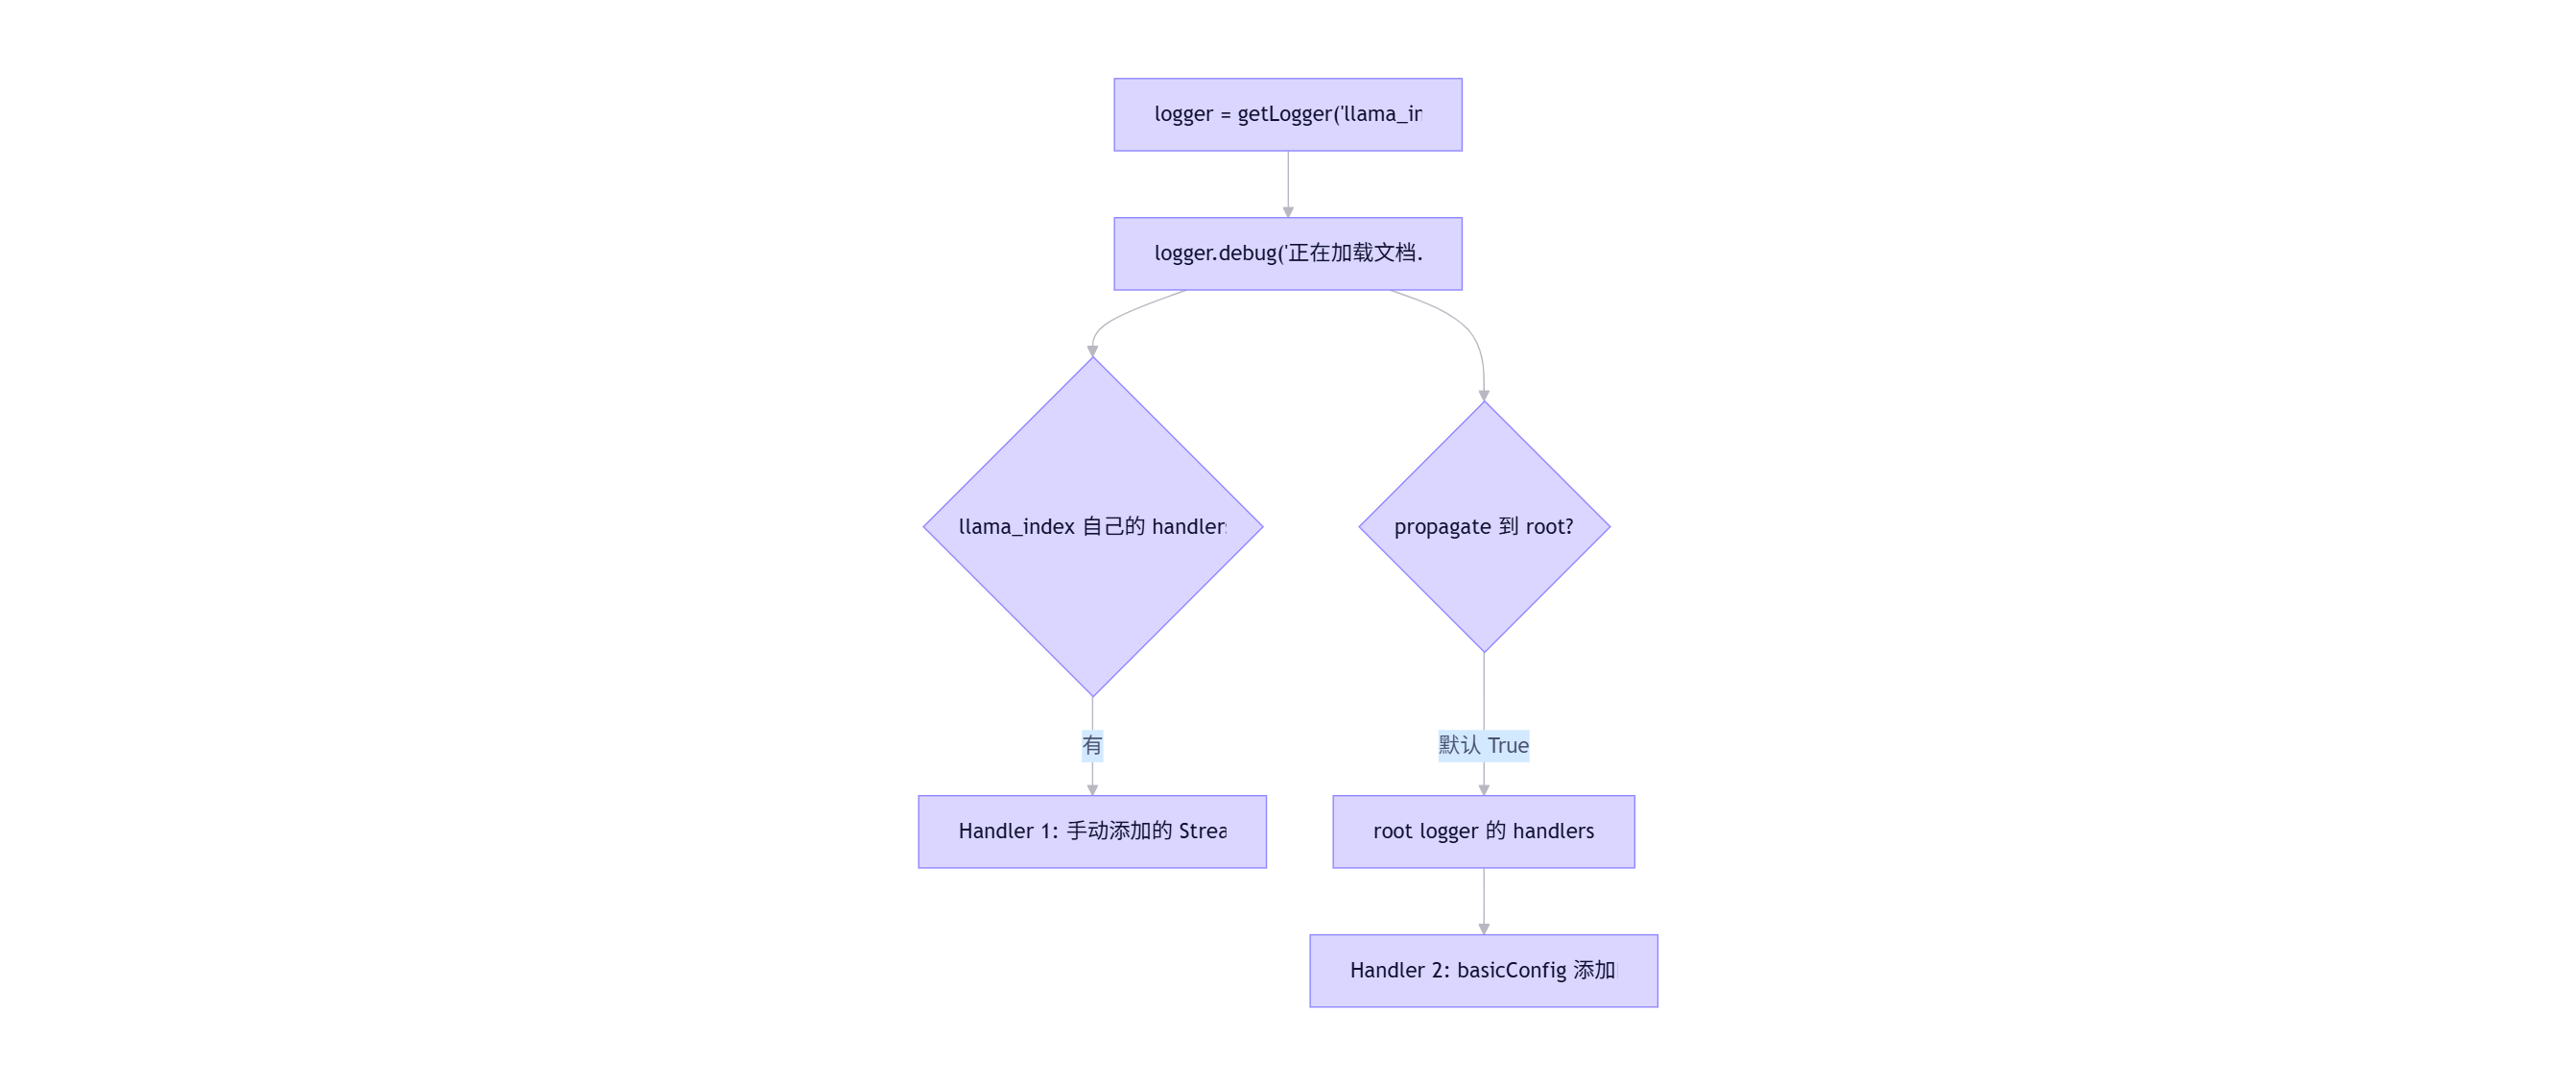

好的！我们来**结合实际输出**，一步步解释日志内容的含义，并说明你那段配置代码会带来什么效果。

---

## 🧪 场景重现：运行你的代码

假设你有如下 Python 脚本（`test_log.py`）：

```python
import sys
import logging

# 你的原始配置
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)
logging.getLogger("llama_index").addHandler(logging.StreamHandler(stream=sys.stdout))

# 获取 logger 并打一条日志
logger = logging.getLogger("llama_index")
logger.debug("正在加载文档...")
```

### 🔽 运行后，终端输出：
```
正在加载文档...
正在加载文档...
```

> ❗ 注意：**同一行日志打印了两次！**

---

## 🔍 结合输出逐层解释日志含义

### ✅ 第一次输出：来自 `basicConfig` 的根处理器（root handler）

- `logging.basicConfig(...)` 给 **根记录器（root logger）** 添加了一个 `StreamHandler`
- `llama_index` 是 `root` 的子 logger，**默认会把日志“冒泡”传递给父级**
- 所以这条日志被 root 的 handler 捕获并输出 → **第一次打印**

> 📌 **含义**：这是全局日志系统按 `DEBUG` 级别正常输出的结果。

---

### ✅ 第二次输出：来自你手动添加的额外处理器

- 你又执行了：
  ```python
  logging.getLogger("llama_index").addHandler(...)
  ```
- 这给 `llama_index` **自己**也加了一个 `StreamHandler`
- 当日志在 `llama_index` 本地生成时，**这个 handler 也会处理它** → **第二次打印**

> 📌 **含义**：这是重复添加 handler 导致的冗余输出。

---

## 🧩 日志系统的内部流程（可视化）

```mermaid
graph TD
    A["logger = getLogger('llama_index')"] --> B["logger.debug('正在加载文档...')"]
    B --> C{"llama_index 自己的 handlers?"}
    C -- 有 --> D[Handler 1: 手动添加的 StreamHandler → 输出第2次]
    B --> E{"propagate 到 root?"}
    E -- 默认 True --> F[root logger 的 handlers]
    F --> G[Handler 2: basicConfig 添加的 StreamHandler → 输出第1次]
```

> 💡 关键属性：`logger.propagate = True`（默认），所以日志会向上传递。

---

## 📊 日志各部分的含义（以标准格式为例）

如果你设置了格式（比如加了 `format` 参数）：

```python
logging.basicConfig(
    stream=sys.stdout,
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
```

输出会变成：
```
2026-02-15 23:45:10,123 - llama_index - DEBUG - 正在加载文档...
2026-02-15 23:45:10,123 - llama_index - DEBUG - 正在加载文档...
```

| 字段 | 含义 |
|------|------|
| `2026-02-15 23:45:10,123` | **时间戳**：日志发生的具体时间 |
| `llama_index` | **Logger 名称**：标识日志来源模块 |
| `DEBUG` | **日志级别**：表示这是调试信息（最低级别） |
| `正在加载文档...` | **日志消息**：开发者想记录的具体内容 |

> ✅ 这种结构化日志便于排查问题、过滤和分析。

---

## ⚠️ 为什么重复日志是个问题？

1. **干扰阅读**：真实日志被淹没在重复信息中
2. **性能损耗**：多一次 I/O 写入（尤其在高并发时）
3. **日志文件膨胀**：磁盘空间浪费

---

## ✅ 正确配置 vs 错误配置对比

### ❌ 你的原始代码（导致重复）
```python
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)
logging.getLogger("llama_index").addHandler(logging.StreamHandler(stream=sys.stdout))  # ← 多余！
```

### ✅ 推荐写法（无重复）
```python
import logging
import sys

# 只配置一次
logging.basicConfig(
    stream=sys.stdout,
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

# 如果需要单独调高 llama_index 的日志级别（可选）
logging.getLogger("llama_index").setLevel(logging.DEBUG)
```

> ✅ 输出：
> ```
> 2026-02-15 23:45:10,123 - llama_index - DEBUG - 正在加载文档...
> ```

---

## 💡 额外技巧：如何检查 logger 的 handlers？

你可以用以下代码诊断：

```python
logger = logging.getLogger("llama_index")
print("Handlers 数量:", len(logger.handlers))
print("是否 propagate:", logger.propagate)
```

- 如果 `len(logger.handlers) > 0` 且 `propagate=True` → **几乎必然重复**

---

## ✅ 总结：结合输出看日志含义

| 输出现象 | 原因 | 日志含义 |
|--------|------|--------|
| 同一日志打印两次 | 重复添加了 handler | 系统同时通过 **本地 handler** 和 **父级 handler** 输出了同一条日志 |
| 只有 WARNING 以上显示 | 未设置 `level=logging.DEBUG` | DEBUG/INFO 被过滤掉了 |
| 无时间/模块名 | 未设置 `format` | 日志缺乏上下文信息，难排查 |

> 🎯 **记住**：  
> **`basicConfig` 已经配置了全局输出，不要再给子 logger 手动加相同的 handler！**

现在你应该能清晰理解日志输出背后的机制了！如果还有疑问，欢迎继续问 😊

# 日志模块有哪些常见用法？给出代码例子